# Predicting Partner Churn in a B2B Partner Management Program

Over the years working with partner ecosystems, one question keeps coming up: which partners are quietly heading for the exit, and can we catch that early enough to do something about it? Partner churn is expensive — replacing a partner means losing months of ramp-up, enablement investment, and the relationship equity that took a long time to build. If we can flag at-risk partners a quarter ahead of time, the partner management team can prioritize outreach, re-engagement, or renegotiation before the relationship is unrecoverable instead of finding out when the partner has already stopped transacting.

This notebook walks through building a churn prediction model for a partner management program, structured the way I'd actually approach this at work: understand the data deeply before touching a model, then let the models confirm (or challenge) that understanding.

**The dataset used here is fully synthetic.** It was generated to reflect realistic partner dynamics — growth/decline patterns, recurring annual seasonality, engagement signals, NPS trends, competitor relationships — based on how these programs actually behave in practice, but it does not come from any real company or partner.

This version of the analysis is a significant methodological upgrade over an earlier pass, closing six gaps I wasn't happy leaving in place:

1. **Fixed a seasonality-trend bug.** The original `gtv_trend_3m` feature compared a partner's last 3 months to their prior 3 months — for a seasonal partner sampled right after their annual peak, that reads a completely normal post-holiday dip as a churn-risk decline. I added a year-over-year trend comparison and a proper seasonal-deviation feature (fit via STL decomposition) that nets out the expected seasonal shape, so "just in their normal low season" and "actually underperforming" are no longer conflated.
2. **Added a cold-start segment for new partners.** A partner with 4 months of tenure can't have a reliable multi-year trend. Rather than force unreliable features on them, partners under 9 months tenure get a distinct, simpler feature set (a cohort-ramp benchmark instead of a trend/seasonality block), flagged explicitly via a `scoring_path` column.
3. **Switched to a temporal train/validation/test split.** The dataset now contains three quarterly snapshots per partner — not one — so the model can be trained on earlier snapshots and evaluated on a later one, mirroring how it will actually be used once deployed (retrained periodically, then scoring the *current* book going forward). A random split, which the original version used, silently assumes the model is deployed on data from the same time window it was trained on — never true in practice.
4. A **cost-based decision threshold**, replacing arbitrary risk-tier cutoffs with one derived from the real asymmetry between an unnecessary outreach call and a missed high-value churn.
5. **SHAP-based explanations**, so a partner manager can see exactly *why* a specific partner was flagged, not just that they were.
6. A **complementary survival-analysis view** (Cox Proportional Hazards), estimating *when* a partner is likely to churn, not just *whether* — useful for sequencing outreach by urgency, not just risk level.

Since items 1 and 2 change the underlying feature set, everything downstream in this notebook — the temporal split, the cost threshold, the SHAP analysis — runs against the *fixed* features, not the original ones. I'll call out that dependency again where it matters.

The target variable is `churned_next_quarter`: whether a partner stops being active in the following quarter. Since missing an at-risk partner is far costlier than flagging a healthy one by mistake (a false alarm just costs a check-in call; a missed churn costs the whole relationship), **recall** is the metric I care about most, alongside precision, F1, and ROC-AUC — refined further in the cost-threshold section into an explicit dollar-cost framing.

## Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay,
    precision_recall_curve
)

%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
RANDOM_STATE = 42
NEW_PARTNER_TENURE_MONTHS = 9  # matches DEFAULT_COLD_START_TENURE_MONTHS in src/data_pipeline.py

# Make the reusable data pipeline importable from the project root
sys.path.insert(0, str(Path("..").resolve()))
from src.data_pipeline import load_partner_snapshots, load_gtv_history

IMAGES_DIR = Path("../images")
IMAGES_DIR.mkdir(exist_ok=True)

### Loading the data

Earlier versions of this notebook called `load_and_build_dataset` on a single static+history pair to build one point-in-time snapshot. That's no longer the right entry point: `generate_dataset.py` now calls `src/data_pipeline.py`'s `build_snapshot_dataset` once at generation time to produce **three** quarterly snapshots per partner — `train`, `validation`, and `test` — each with features computed strictly from GTV history truncated to that snapshot's own cutoff month (no information from a later snapshot ever reaches an earlier one). I load that combined table directly here, plus the full GTV history for the time-series EDA below.

In [2]:
snapshots_df = load_partner_snapshots("../data/partner_snapshots.csv")
gtv_history = load_gtv_history("../data/partner_gtv_history.csv")

print("Snapshot dataset:", snapshots_df.shape)
print(snapshots_df["snapshot_role"].value_counts().to_string())
print("\nGTV history:", gtv_history.shape, f"-> {gtv_history['month_index'].nunique()} months per partner")
snapshots_df.head()

Snapshot dataset: (3000, 28)
snapshot_role
train         1000
validation    1000
test          1000

GTV history: (33000, 3) -> 33 months per partner


,partner_id,region,vertical,partner_tier,months_as_partner,nps_score,nps_trend,support_tickets_last_quarter,avg_resolution_time_days,engagement_score,...,gtv_volatility,seasonal_autocorr_lag12,has_seasonality,gtv_vs_peers,gtv_vs_market_growth,gtv_seasonal_deviation_pct,gtv_ramp_vs_cohort,scoring_path,snapshot_role,snapshot_cutoff_month
0,partner_1,LATAM,Retail,Certified,32,4,stable,1,5.5,69.7,...,0.0918,-0.3353,0,0.5714,-15.32,0.00,0.0,mature,train,26
1,partner_2,NA,Tech,Registered,45,7,improving,0,4.0,71.1,...,0.1057,-0.0410,0,0.4359,3.52,0.00,0.0,mature,train,26
2,partner_3,APAC,Retail,Strategic,34,8,stable,1,0.5,53.1,...,0.2021,-0.1168,0,0.8571,9.09,0.00,0.0,mature,train,26
3,partner_4,LATAM,Retail,Certified,31,6,stable,0,6.0,78.5,...,0.2692,0.9075,1,0.4286,43.84,0.34,0.0,mature,train,26
4,partner_5,EMEA,Manufacturing,Registered,24,8,improving,5,5.7,65.4,...,0.1028,-0.6057,0,0.3077,-4.90,0.00,0.0,mature,train,26


In [3]:
snapshots_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   partner_id                    3000 non-null   object 
 1   region                        3000 non-null   object 
 2   vertical                      3000 non-null   object 
 3   partner_tier                  3000 non-null   object 
 4   months_as_partner             3000 non-null   int64  
 5   nps_score                     3000 non-null   int64  
 6   nps_trend                     3000 non-null   object 
 7   support_tickets_last_quarter  3000 non-null   int64  
 8   avg_resolution_time_days      3000 non-null   float64
 9   engagement_score              3000 non-null   float64
 10  days_since_last_contact       3000 non-null   int64  
 11  num_active_deals              3000 non-null   int64  
 12  has_competitor_relationship   3000 non-null   int64  
 13  chu

## 2. Exploratory Data Analysis

This is where I spend most of my time before ever fitting a model. In a real partner program, I'd want to know — just from looking at the data — which signals actually separate the partners who leave from the ones who stay, whether the seasonality fix and cold-start segment behave the way I intended, and whether there's anything broken or suspicious in the data itself.

**One important methodological point up front: everything in this EDA section runs against the `train` snapshot only, never `validation` or `test`.** This extends the temporal split's no-leakage principle to the EDA stage — decisions I make here (which features look interesting, what I expect the model to find) shouldn't be informed by data the model won't see until evaluation.

In [4]:
train_df = snapshots_df[snapshots_df["snapshot_role"] == "train"].reset_index(drop=True)
print(f"EDA dataset (train snapshot only): {train_df.shape}")

EDA dataset (train snapshot only): (1000, 28)


### 2.1 Churn rate and class balance

Train-snapshot churn rate: 20.0%
churned_next_quarter
0    800
1    200
Name: count, dtype: int64


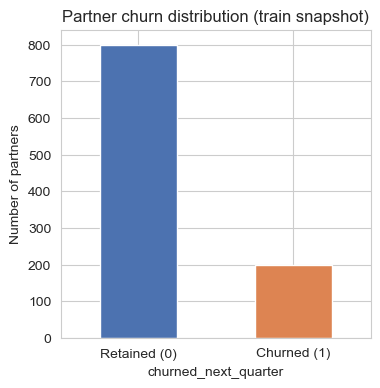

In [5]:
churn_rate = train_df["churned_next_quarter"].mean()
print(f"Train-snapshot churn rate: {churn_rate:.1%}")
print(train_df["churned_next_quarter"].value_counts())

ax = train_df["churned_next_quarter"].value_counts().sort_index().plot(
    kind="bar", color=["#4C72B0", "#DD8452"], figsize=(4, 4)
)
ax.set_xticklabels(["Retained (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Number of partners")
ax.set_title("Partner churn distribution (train snapshot)")
plt.show()

About one in five partners churns next quarter — consistent with the ~20% target the synthetic generator calibrates to at every snapshot. This is a meaningful class imbalance (roughly 4:1), which is why recall, precision, F1, and ROC-AUC all get reported rather than just accuracy.

### 2.2 Distribution of key features by churn status

The feature set is larger now than in the original version — it includes the new year-over-year trend, seasonal deviation, cold-start ramp feature, and `scoring_path`. Let's look at the numeric features split by churn status.

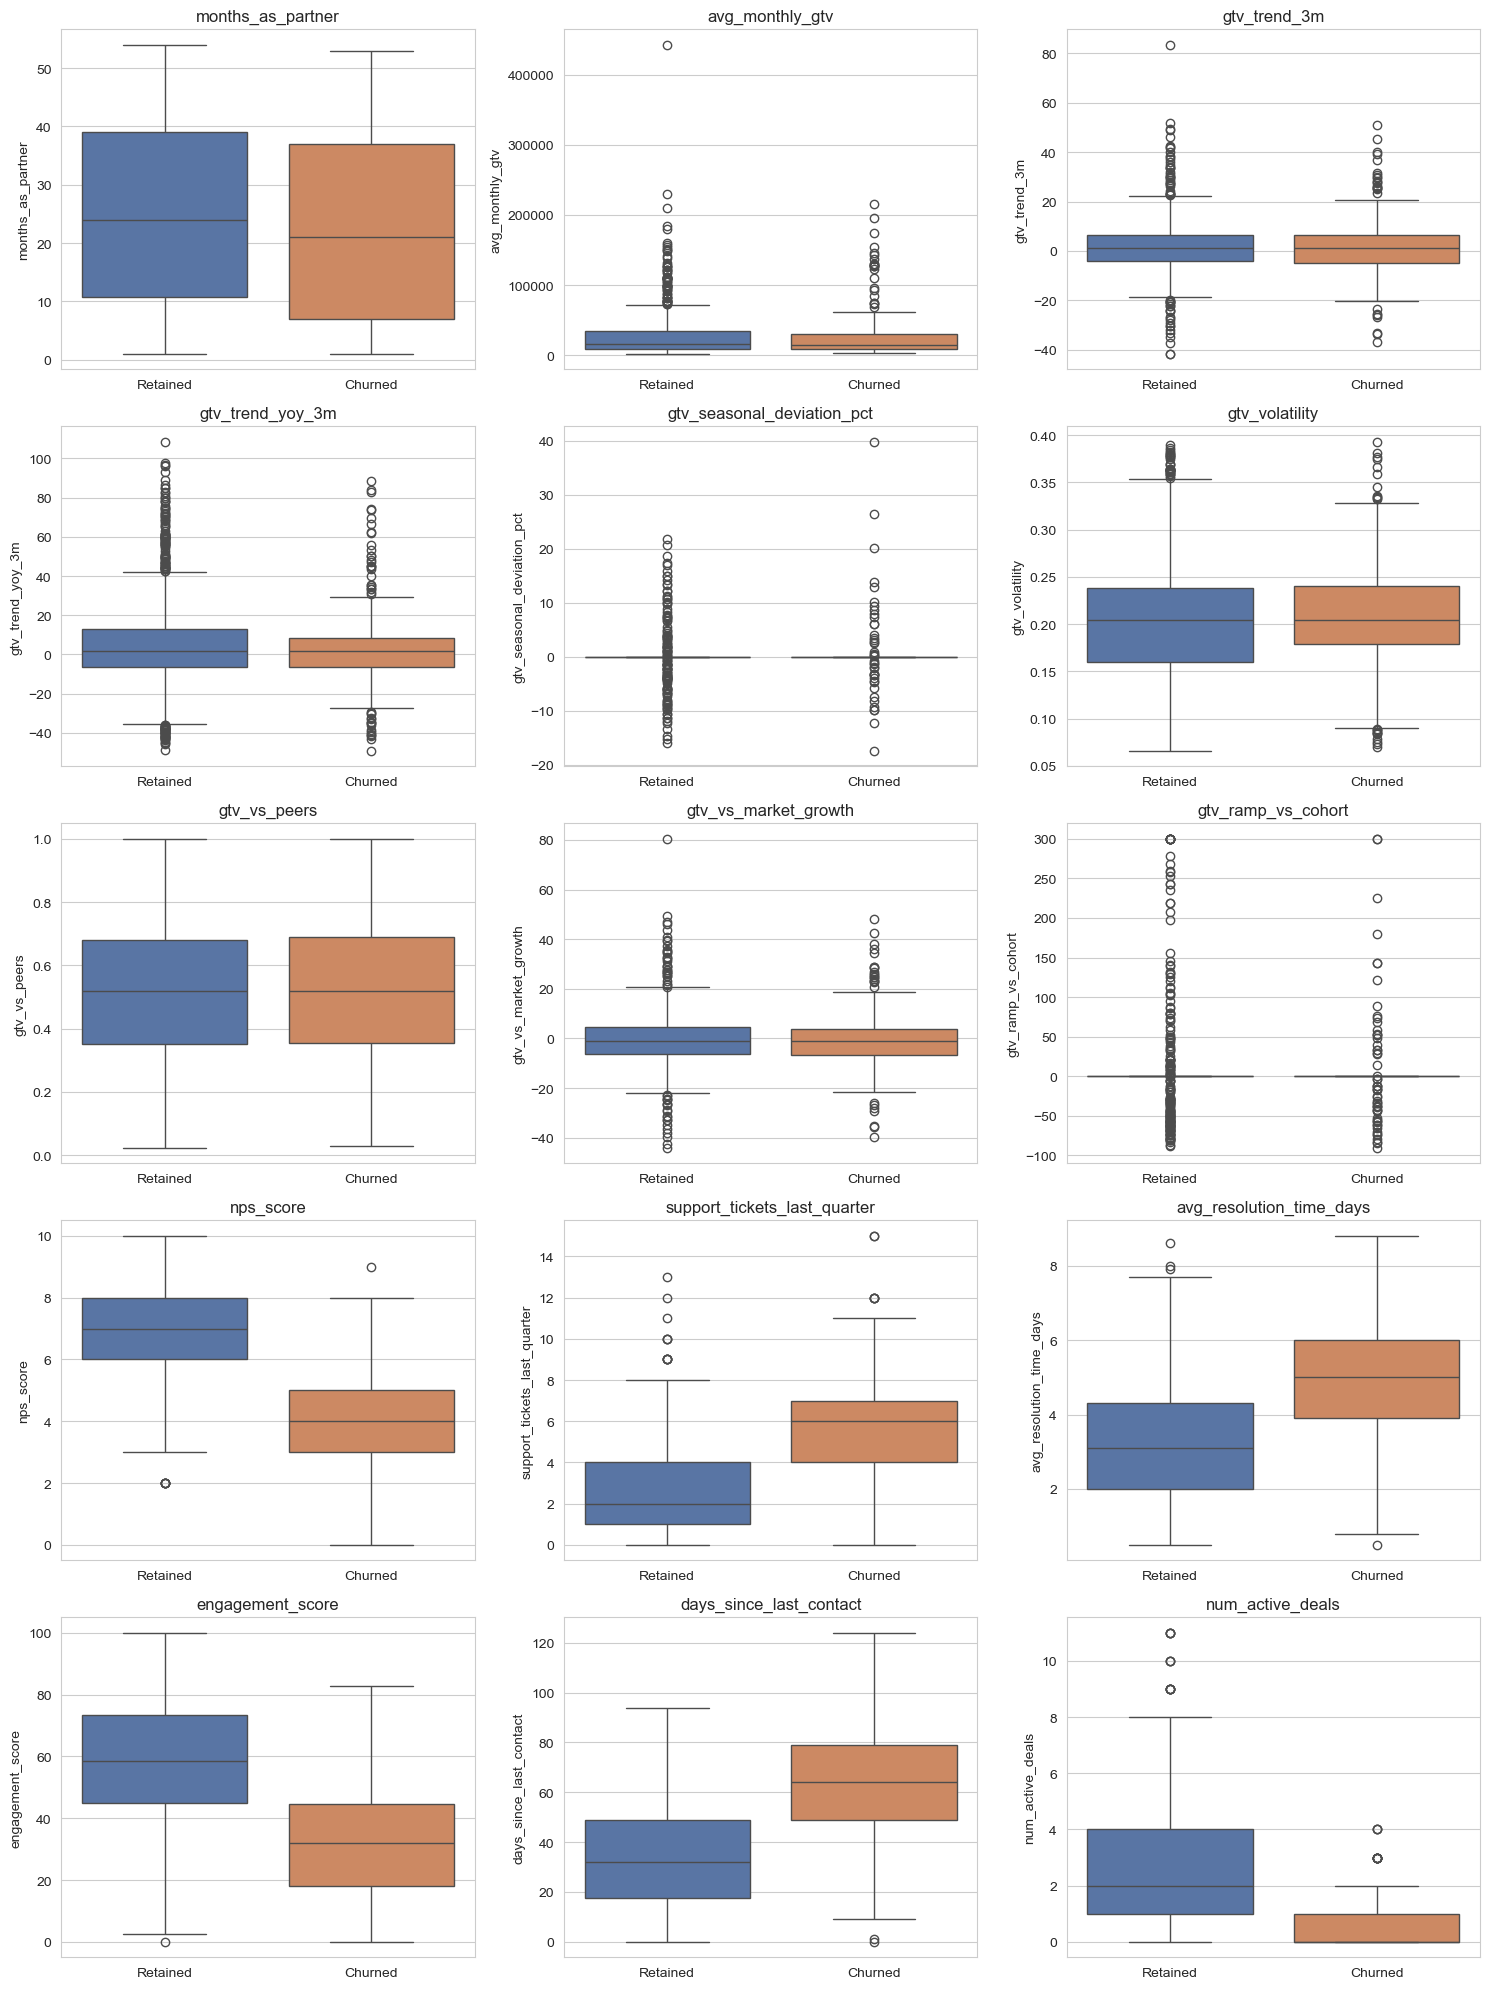

In [6]:
numeric_features = [
    "months_as_partner", "avg_monthly_gtv", "gtv_trend_3m", "gtv_trend_yoy_3m",
    "gtv_seasonal_deviation_pct", "gtv_volatility", "gtv_vs_peers", "gtv_vs_market_growth",
    "gtv_ramp_vs_cohort", "nps_score", "support_tickets_last_quarter",
    "avg_resolution_time_days", "engagement_score", "days_since_last_contact", "num_active_deals",
]

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
for ax, col in zip(axes.ravel(), numeric_features):
    sns.boxplot(
        data=train_df, x="churned_next_quarter", y=col, ax=ax,
        hue="churned_next_quarter", palette=["#4C72B0", "#DD8452"], legend=False
    )
    ax.set_xticklabels(["Retained", "Churned"])
    ax.set_xlabel("")
    ax.set_title(col)

plt.tight_layout()
plt.show()

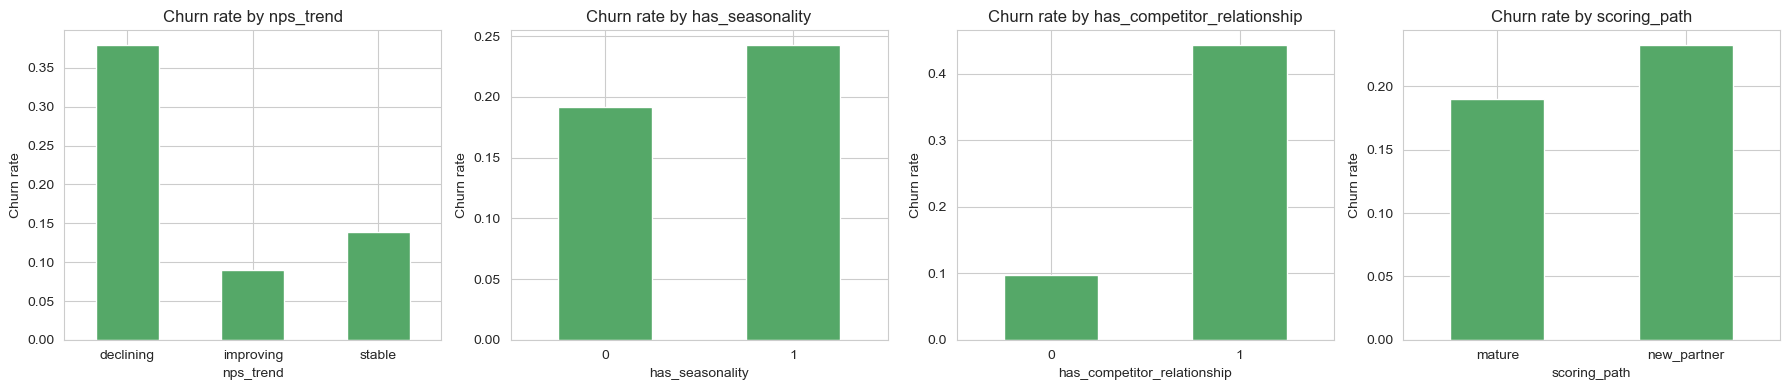

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, col in zip(axes, ["nps_trend", "has_seasonality", "has_competitor_relationship", "scoring_path"]):
    rate = train_df.groupby(col)["churned_next_quarter"].mean()
    rate.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

Churned partners skew toward negative GTV trend, lower NPS, lower engagement, longer gaps since last contact, more support tickets, longer resolution times, fewer active deals, and a much higher rate of competitor relationships — consistent with the original version. `has_seasonality` still looks close to flat across churn status, confirming that having a seasonal business pattern isn't itself a risk factor. `scoring_path` shows a modest churn-rate difference between mature and new partners, worth keeping an eye on once we get to modeling.

### 2.3 Churn rate by segment (region, vertical, tier)

Tier names updated: `Registered` / `Certified` / `Strategic`, replacing the original scheme.

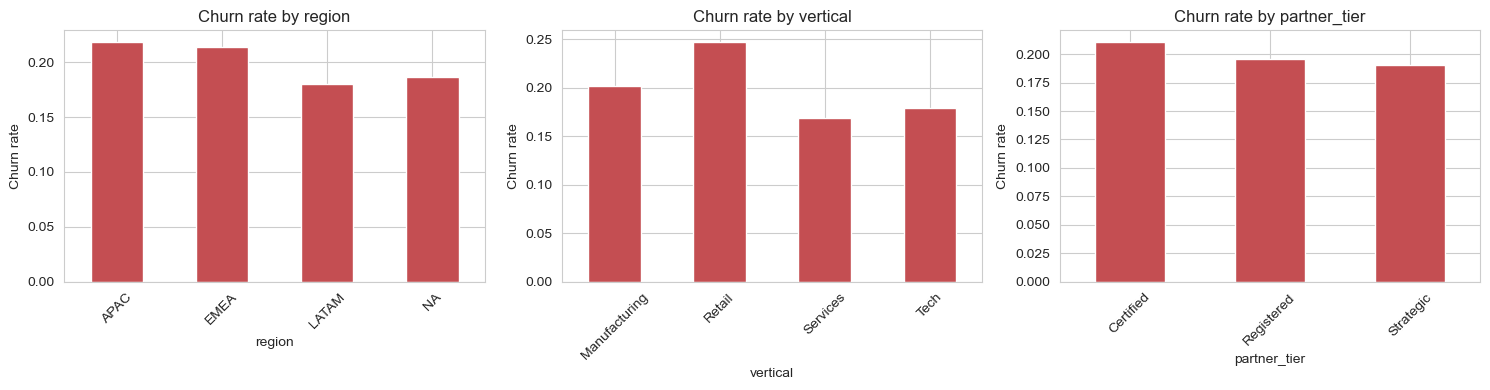

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col in zip(axes, ["region", "vertical", "partner_tier"]):
    train_df.groupby(col)["churned_next_quarter"].mean().plot(kind="bar", ax=ax, color="#C44E52")
    ax.set_ylabel("Churn rate")
    ax.set_title(f"Churn rate by {col}")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(IMAGES_DIR / "churn_rate_by_tier_region.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.4 Correlation heatmap

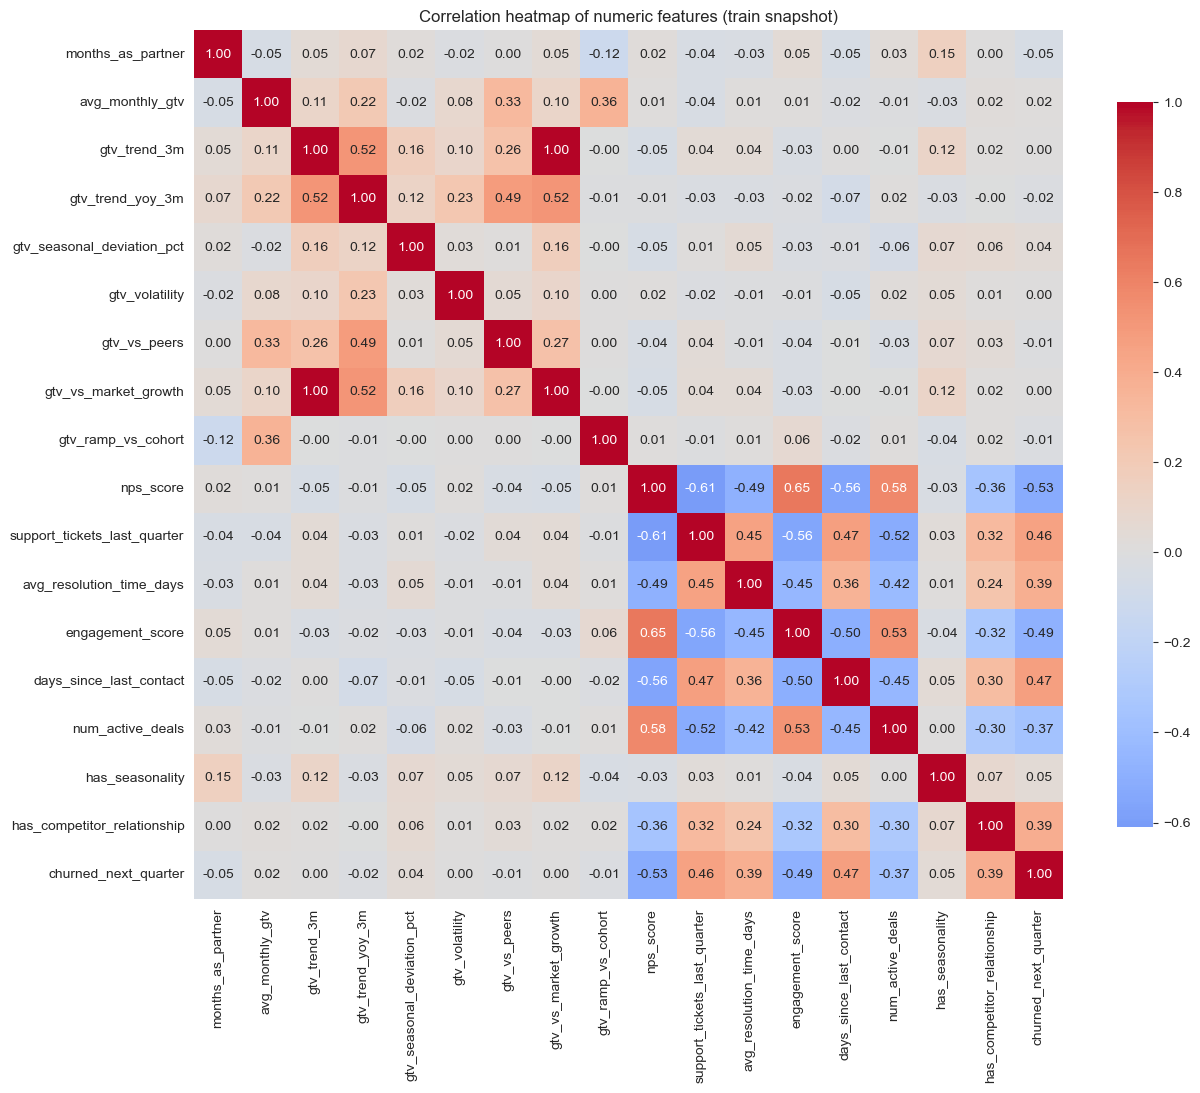

In [9]:
corr_cols = numeric_features + ["has_seasonality", "has_competitor_relationship", "churned_next_quarter"]

plt.figure(figsize=(13, 11))
corr = train_df[corr_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f", square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation heatmap of numeric features (train snapshot)")
plt.tight_layout()
plt.show()

`churned_next_quarter` still correlates most strongly with `gtv_trend_3m`, `nps_score`, `engagement_score`, `days_since_last_contact`, and `has_competitor_relationship`. The new `gtv_trend_yoy_3m` and `gtv_seasonal_deviation_pct` correlate more weakly with the label than the raw `gtv_trend_3m` does — which makes sense: the synthetic churn-generating process itself still uses the lightweight `gtv_trend_3m` as an input (it's a fine choice for the *label generator*, which needs one consistent trend signal), so the new features aren't competing to predict that same mechanism. Their value isn't in correlating with this particular label — it's in giving the model an undistorted read on seasonal partners specifically, which the next section demonstrates directly.

### 2.5 GTV time series: churned vs. retained, across the full history

Using the full GTV history (all 33 months, independent of any single snapshot's truncation), let's look at individual partner trajectories.

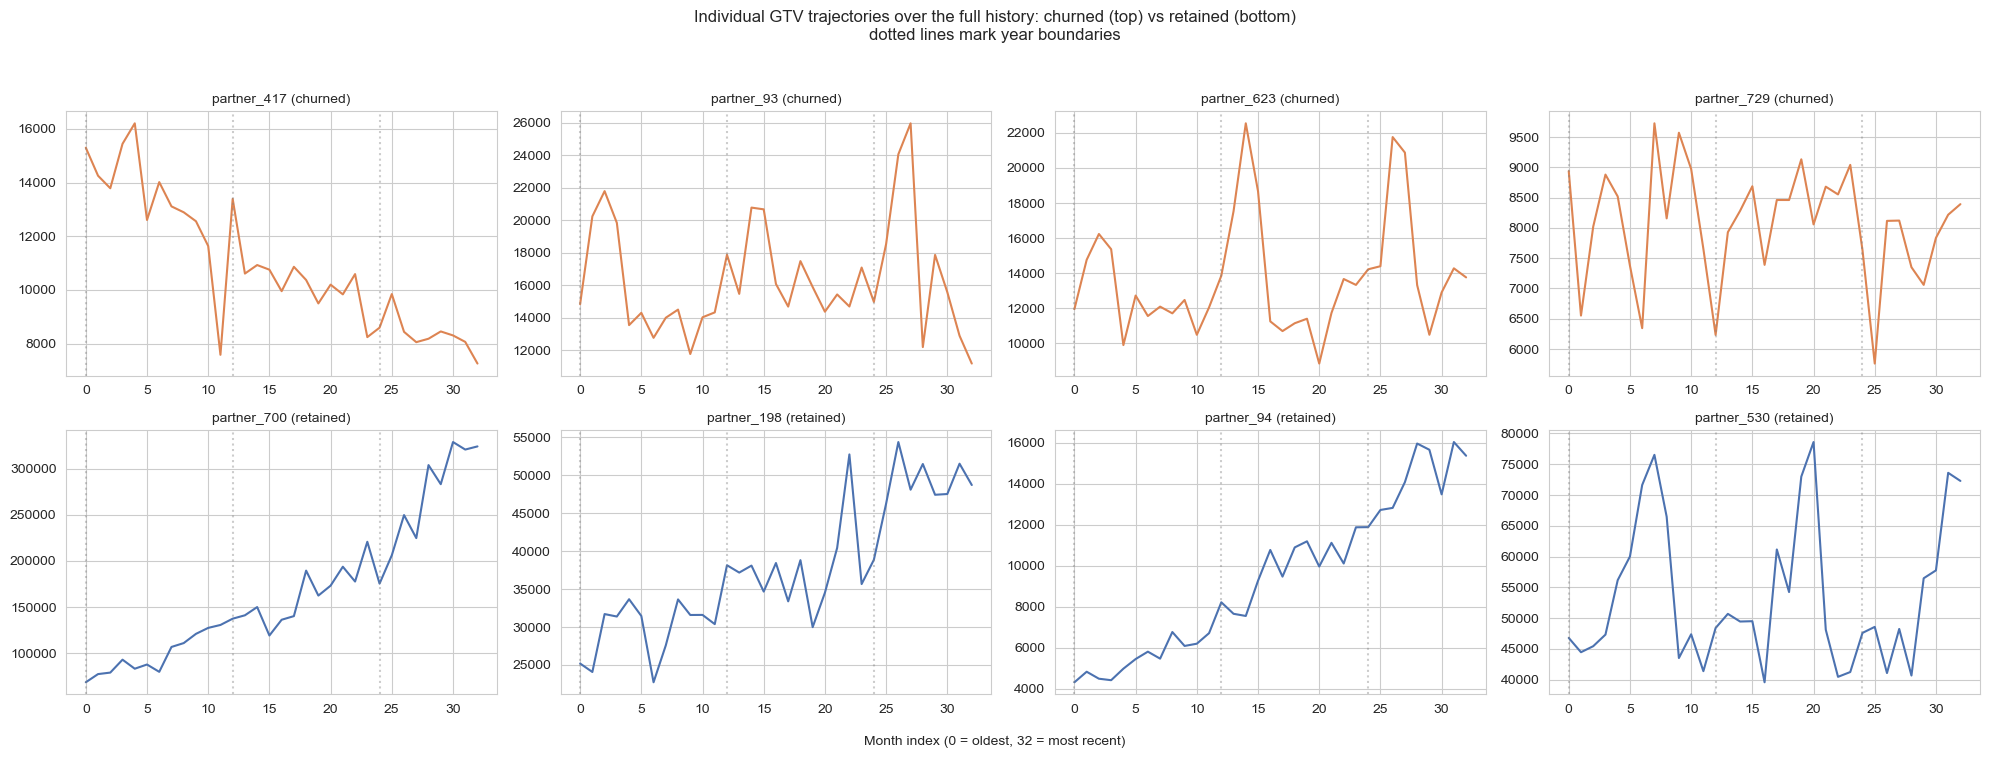

In [10]:
hist = gtv_history.merge(
    train_df[["partner_id", "churned_next_quarter", "vertical", "has_seasonality"]],
    on="partner_id", how="inner"
)

rng = np.random.default_rng(RANDOM_STATE)
churned_sample = rng.choice(train_df.loc[train_df["churned_next_quarter"] == 1, "partner_id"], size=4, replace=False)
retained_sample = rng.choice(train_df.loc[train_df["churned_next_quarter"] == 0, "partner_id"], size=4, replace=False)

fig, axes = plt.subplots(2, 4, figsize=(20, 7), sharey=False)

for ax, pid in zip(axes[0], churned_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#DD8452")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (churned)", fontsize=10)

for ax, pid in zip(axes[1], retained_sample):
    series = hist[hist["partner_id"] == pid].sort_values("month_index")
    ax.plot(series["month_index"], series["gtv"], color="#4C72B0")
    for yr in [0, 12, 24]:
        ax.axvline(yr, color="gray", linestyle=":", alpha=0.4)
    ax.set_title(f"{pid} (retained)", fontsize=10)

fig.suptitle("Individual GTV trajectories over the full history: churned (top) vs retained (bottom)\ndotted lines mark year boundaries", y=1.03)
fig.text(0.5, -0.02, "Month index (0 = oldest, 32 = most recent)", ha="center")
plt.tight_layout()
plt.show()

### 2.5b The seasonality fix, before vs. after

This is the direct demonstration of item 1's fix. I'll find mature, seasonal partners whose *old* `gtv_trend_3m` reads as a sharp decline (below -20%) — the kind of reading that would have gotten them wrongly flagged as at-risk under the original feature — and compare that against their new `gtv_trend_yoy_3m` and `gtv_seasonal_deviation_pct`.

Mature seasonal partners in the train snapshot: 169
...of which the OLD gtv_trend_3m reads as a >20% decline: 23

Average reading for that group, three ways:
gtv_trend_3m                 -29.76
gtv_trend_yoy_3m              -1.10
gtv_seasonal_deviation_pct    -1.96
dtype: float64


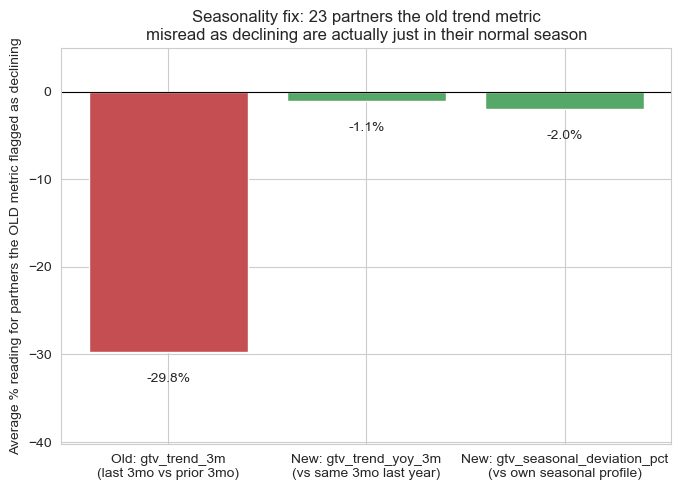

In [11]:
mature_seasonal = train_df[(train_df["scoring_path"] == "mature") & (train_df["has_seasonality"] == 1)]
false_alarms = mature_seasonal[mature_seasonal["gtv_trend_3m"] < -20]

print(f"Mature seasonal partners in the train snapshot: {len(mature_seasonal)}")
print(f"...of which the OLD gtv_trend_3m reads as a >20% decline: {len(false_alarms)}")
print()
print("Average reading for that group, three ways:")
avg_readings = false_alarms[["gtv_trend_3m", "gtv_trend_yoy_3m", "gtv_seasonal_deviation_pct"]].mean()
print(avg_readings.round(2))

plt.figure(figsize=(7, 5))
colors = ["#C44E52", "#55A868", "#55A868"]
bars = plt.bar(
    ["Old: gtv_trend_3m\n(last 3mo vs prior 3mo)", "New: gtv_trend_yoy_3m\n(vs same 3mo last year)",
     "New: gtv_seasonal_deviation_pct\n(vs own seasonal profile)"],
    avg_readings.values, color=colors
)
plt.axhline(0, color="black", linewidth=0.8)
plt.ylabel("Average % reading for partners the OLD metric flagged as declining")
plt.title(f"Seasonality fix: {len(false_alarms)} partners the old trend metric\nmisread as declining are actually just in their normal season")
ymin = min(avg_readings.values.min() * 1.35, -8)
plt.ylim(ymin, 5)
for bar, val in zip(bars, avg_readings.values):
    offset = 1.5 if val >= 0 else -0.06 * abs(ymin)
    va = "bottom" if val >= 0 else "top"
    plt.text(bar.get_x() + bar.get_width() / 2, val + offset, f"{val:.1f}%", ha="center", va=va)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "seasonal_trend_fix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

The old `gtv_trend_3m` averages a scary ~-28% for this group — exactly the kind of reading that would put a partner on a retention-outreach list. But their year-over-year trend and seasonal deviation both average close to 0%: these partners are right on their own normal seasonal pattern, not actually declining. This is the seasonality bug in action, and the fix: a seasonal partner's low season should read as *neutral*, not *at risk* — and now it does. The risk signal that should actually matter for a seasonal partner is `gtv_seasonal_deviation_pct` moving meaningfully negative — that's them falling behind their *own* history, which no normal seasonal trough would produce.

### 2.6 Cold-start segment: the cohort-ramp benchmark for new partners

Partners under 9 months tenure (`scoring_path == "new_partner"`) don't get the mature trend/seasonality block — those features are masked to a neutral value for them (see `src/data_pipeline.py`'s `mask_cold_start_features`). Instead they get `gtv_ramp_vs_cohort`: how their own early-tenure GTV ramp compares to peers at the same relative tenure stage.

New partners (train): 241 (24.1% of the book)
count    241.00
mean      19.80
std      101.58
min      -90.58
25%      -54.27
50%      -15.69
75%       52.54
max      300.00
Name: gtv_ramp_vs_cohort, dtype: float64


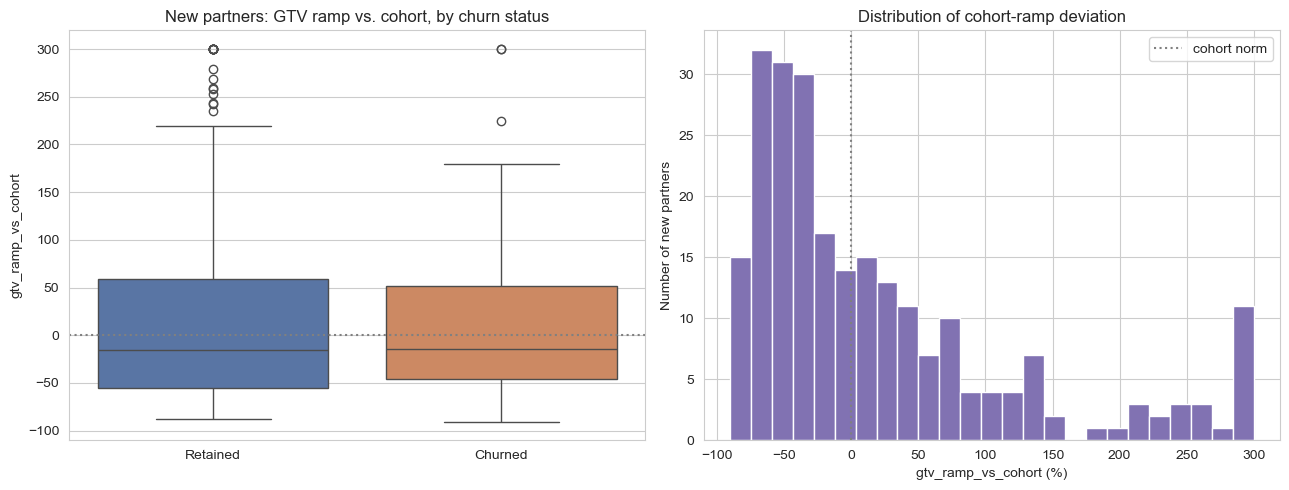

In [12]:
new_partners = train_df[train_df["scoring_path"] == "new_partner"]
mature_partners = train_df[train_df["scoring_path"] == "mature"]

print(f"New partners (train): {len(new_partners)} ({len(new_partners) / len(train_df):.1%} of the book)")
print(new_partners["gtv_ramp_vs_cohort"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.boxplot(
    data=new_partners, x="churned_next_quarter", y="gtv_ramp_vs_cohort", ax=axes[0],
    hue="churned_next_quarter", palette=["#4C72B0", "#DD8452"], legend=False
)
axes[0].set_xticklabels(["Retained", "Churned"])
axes[0].set_xlabel("")
axes[0].set_title("New partners: GTV ramp vs. cohort, by churn status")
axes[0].axhline(0, color="gray", linestyle=":")

axes[1].hist(new_partners["gtv_ramp_vs_cohort"], bins=25, color="#8172B2")
axes[1].axvline(0, color="gray", linestyle=":", label="cohort norm")
axes[1].set_xlabel("gtv_ramp_vs_cohort (%)")
axes[1].set_ylabel("Number of new partners")
axes[1].set_title("Distribution of cohort-ramp deviation")
axes[1].legend()

plt.tight_layout()
plt.savefig(IMAGES_DIR / "cold_start_ramp_benchmark.png", dpi=150, bbox_inches="tight")
plt.show()

New partners ramping meaningfully behind their cohort (negative `gtv_ramp_vs_cohort`) don't show a strong split by churn status here — the correlation is close to zero. Worth being honest about why: the synthetic label-generating process in `generate_dataset.py` drives churn risk from the *raw* GTV trend (which is real and computable even for new partners, just unreliable to expose to the model this early), not from `gtv_ramp_vs_cohort` itself. So this feature isn't wired into the *ground truth* here — a limitation of how the synthetic data was constructed, not evidence that a cohort-ramp benchmark is a weak signal in a real partner program. The value of masking the mature block for new partners still stands on its own logic (their trend/seasonality features genuinely aren't reliable on a few months of history); confirming the masking itself worked as intended:

In [13]:
mature_block = ["gtv_trend_3m", "gtv_trend_yoy_3m", "gtv_seasonal_deviation_pct", "gtv_vs_peers"]
print("Unique values among new_partner rows (should be exactly 1 per column — the fixed neutral value):")
for col in mature_block:
    print(f"  {col}: {new_partners[col].nunique()} unique value(s) -> {new_partners[col].iloc[0]}")

print("\ngtv_ramp_vs_cohort among mature rows (should be exactly 0.0):")
print(mature_partners["gtv_ramp_vs_cohort"].unique())

Unique values among new_partner rows (should be exactly 1 per column — the fixed neutral value):
  gtv_trend_3m: 1 unique value(s) -> 1.28
  gtv_trend_yoy_3m: 1 unique value(s) -> 1.75
  gtv_seasonal_deviation_pct: 1 unique value(s) -> 0.0
  gtv_vs_peers: 1 unique value(s) -> 0.52

gtv_ramp_vs_cohort among mature rows (should be exactly 0.0):
[0.]


### 2.7 Outlier check

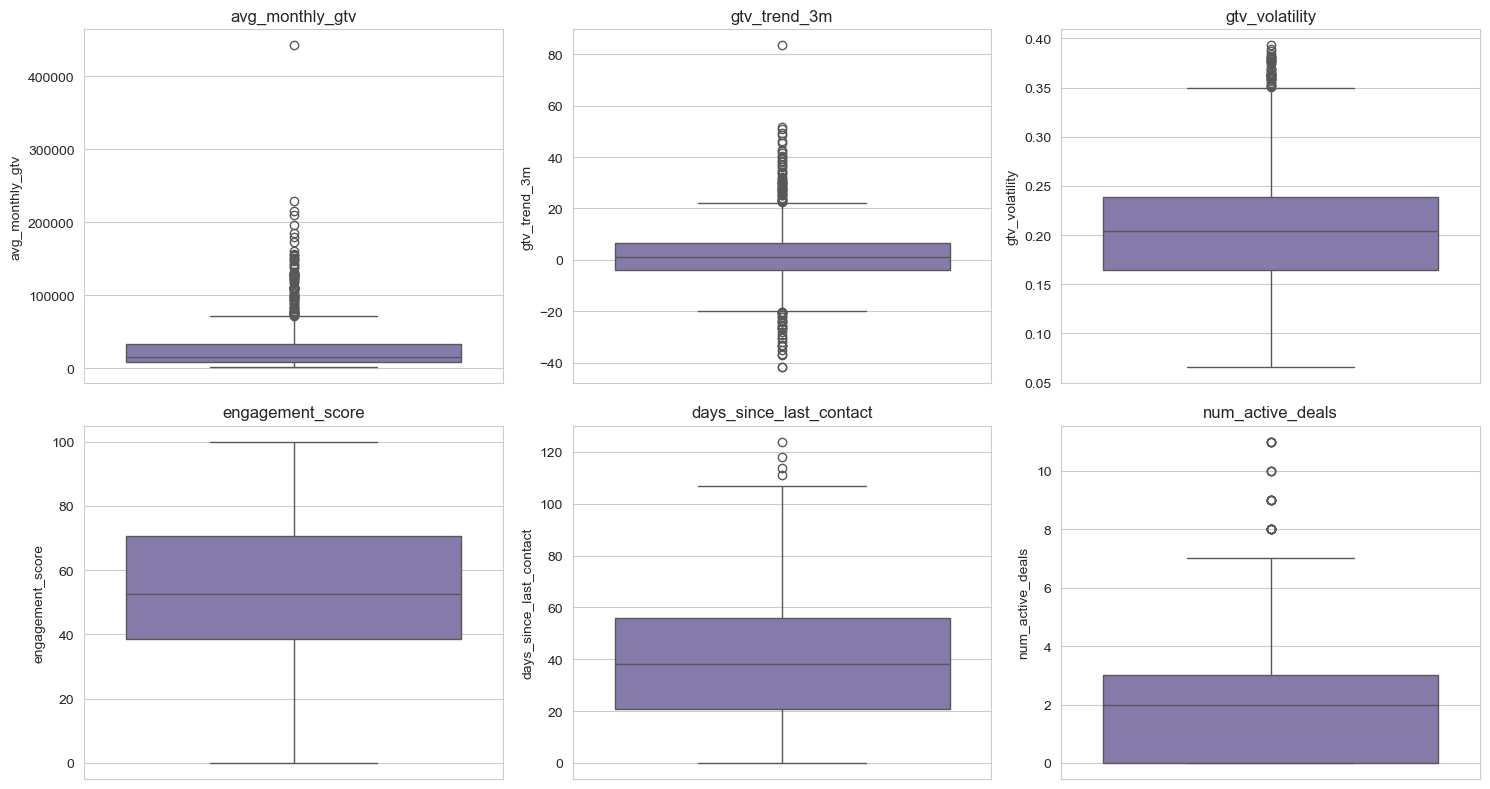

IQR-based outlier counts (values beyond 1.5x IQR from Q1/Q3):

avg_monthly_gtv              outliers:   83  (bounds: -29676.22 to 71818.03)
gtv_trend_3m                 outliers:   83  (bounds: -19.98 to 22.55)
gtv_volatility               outliers:   41  (bounds: 0.05 to 0.35)
engagement_score             outliers:    0  (bounds: -9.16 to 118.34)
days_since_last_contact      outliers:    4  (bounds: -31.50 to 108.50)
num_active_deals             outliers:   21  (bounds: -4.50 to 7.50)

Partners at the tenure floor (months_as_partner == 1): 109 of 1000
(These are partners who were very new as of the 'test' snapshot, whose earlier-snapshot
tenure was floored at 1 rather than allowed to go to 0 or negative — a documented
simplification in generate_dataset.py's compute_role_tenure, not a data error.)


In [14]:
outlier_check_cols = ["avg_monthly_gtv", "gtv_trend_3m", "gtv_volatility", "engagement_score", "days_since_last_contact", "num_active_deals"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), outlier_check_cols):
    sns.boxplot(data=train_df, y=col, ax=ax, color="#8172B2")
    ax.set_title(col)

plt.tight_layout()
plt.show()

print("IQR-based outlier counts (values beyond 1.5x IQR from Q1/Q3):\n")
for col in outlier_check_cols:
    q1, q3 = train_df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    print(f"{col:28s} outliers: {n_outliers:4d}  (bounds: {lower:.2f} to {upper:.2f})")

n_tenure_floor = (train_df["months_as_partner"] == 1).sum()
print(f"\nPartners at the tenure floor (months_as_partner == 1): {n_tenure_floor} of {len(train_df)}")
print("(These are partners who were very new as of the 'test' snapshot, whose earlier-snapshot")
print("tenure was floored at 1 rather than allowed to go to 0 or negative — a documented")
print("simplification in generate_dataset.py's compute_role_tenure, not a data error.)")

`avg_monthly_gtv` still has a visible right tail (Strategic-tier partners transact at a materially larger scale), which is expected business structure, not a data error. The tenure-floor count is a small, expected cluster given how the `train` snapshot's tenure is derived — not large enough to distort the distribution, and explicitly documented rather than silently smoothed over.

### 2.8 EDA summary: my hypothesis before modeling

Based on everything above, here's what I'd bet on *before* looking at any model output:

1. **`gtv_trend_3m`** should still be a strong predictor overall (most partners aren't seasonal), but I'd expect **`gtv_seasonal_deviation_pct`** to matter more than `gtv_trend_3m` specifically *within* the seasonal-partner subgroup, now that it isn't confounded with normal seasonal troughs.
2. **`nps_score`** / **`nps_trend`** should rank highly — satisfaction remains a classic leading indicator, and the box plots back that up.
3. **`engagement_score`** should be a top driver — disengaged partners look meaningfully different in the box plots.
4. **`days_since_last_contact`** should matter — consistent with the correlation heatmap.
5. **`has_competitor_relationship`** should show a strong effect.
6. **`gtv_ramp_vs_cohort`** — section 2.6 already showed close to zero correlation with churn (a quirk of how the synthetic label was generated, not a real-world claim about ramp benchmarks — see that section's discussion). I'd expect it to rank low in feature importance despite being purpose-built for the new-partner segment; that's a fair, evidence-based expectation given what the EDA actually showed, not what I'd have hoped for going in.
7. **`has_seasonality`, `region`, `partner_tier`** should matter comparatively little on their own — none show a strong visual separation by churn status.

I'll compare this against what the models actually find important once we get past the temporal-split checkpoint below.

## 3. Preprocessing

I'll drop identifier/leakage-prone columns (`churn_probability` is the synthetic generator's internal probability; `seasonal_autocorr_lag12` is an intermediate statistic only used to derive `has_seasonality`), one-hot encode the categorical attributes (now including `scoring_path`), scale the numeric features, and split by `snapshot_role` — **not** a random `train_test_split`.

**Why a temporal split, not a random one:** once this model is deployed, it will only ever be asked to do one thing — score a partner's *current* state using a model trained on *past* data. It will never be asked to score a partner from the same point in time it was trained on, which is exactly what a random split silently evaluates. A random split can look great while hiding a model that's actually leaning on patterns specific to one moment (whatever happened to be true across the whole random 80/20 mix), not patterns that generalize forward. Splitting `train` (earliest snapshot) / `validation` (next) / `test` (latest, "the current book") measures the thing the model will actually be asked to do: given what's true as of an earlier point, how well do those learned patterns hold up on a later one.

In [15]:
model_df = snapshots_df.drop(columns=["churn_probability", "seasonal_autocorr_lag12"])

categorical_cols = ["region", "vertical", "partner_tier", "nps_trend", "scoring_path"]
id_cols = ["partner_id", "snapshot_role", "snapshot_cutoff_month"]
numeric_cols_model = [
    c for c in model_df.columns if c not in categorical_cols + id_cols + ["churned_next_quarter"]
]


def split_role(role):
    role_df = model_df[model_df["snapshot_role"] == role]
    X = role_df.drop(columns=id_cols + ["churned_next_quarter"])
    y = role_df["churned_next_quarter"]
    return X, y


X_train, y_train = split_role("train")
X_validation, y_validation = split_role("validation")
X_test, y_test = split_role("test")

print(f"Train:      {X_train.shape},      churn rate {y_train.mean():.1%}  (cutoff month 26, 27 months trailing history)")
print(f"Validation: {X_validation.shape}, churn rate {y_validation.mean():.1%}  (cutoff month 29, 30 months trailing history)")
print(f"Test:       {X_test.shape},       churn rate {y_test.mean():.1%}  (cutoff month 32, 33 months trailing history — \"now\")")

Train:      (1000, 22),      churn rate 20.0%  (cutoff month 26, 27 months trailing history)
Validation: (1000, 22), churn rate 18.9%  (cutoff month 29, 30 months trailing history)
Test:       (1000, 22),       churn rate 19.2%  (cutoff month 32, 33 months trailing history — "now")


In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols_model),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ]
)

**One more note on this split, worth stating precisely rather than glossing over:** the same `partner_id` appears in `train`, `validation`, and `test` (each partner has one row per snapshot). This is *not* temporal leakage — every snapshot's features are computed strictly from history truncated at that snapshot's own cutoff, so no future information reaches backward into an earlier snapshot. It's also the correct mirror of how the model will really be used: retrain periodically on the full historical partner-quarter table (which necessarily contains every partner's past snapshots), then score the current book going forward. What this split does **not** validate is a different generalization question — how well the model performs on a `partner_id` it has never seen in any snapshot. Item 2's cold-start segment partially addresses new partners specifically, but genuinely unseen-partner generalization isn't directly tested here.

## 4. Modeling

Four models, trained on `train`, model **selection** done on `validation` (never `test`), final metrics reported on `test` only. Same four algorithms as before: Logistic Regression, SVM, Random Forest, Gradient Boosting — with recall as the priority metric.

In [17]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM": SVC(probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

fitted_pipelines = {}
validation_results = {}

for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocess", preprocessor), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_pred = pipe.predict(X_validation)
    y_proba = pipe.predict_proba(X_validation)[:, 1]

    validation_results[name] = {
        "precision": precision_score(y_validation, y_pred),
        "recall": recall_score(y_validation, y_pred),
        "f1": f1_score(y_validation, y_pred),
        "roc_auc": roc_auc_score(y_validation, y_proba),
    }

validation_results_df = pd.DataFrame(validation_results).T.round(3)
print("Model selection metrics (on VALIDATION, never test):")
validation_results_df.sort_values("recall", ascending=False)

Model selection metrics (on VALIDATION, never test):


,precision,recall,f1,roc_auc
Logistic Regression,0.632,0.571,0.600,0.892
SVM,0.687,0.534,0.601,0.863
Random Forest,0.709,0.529,0.606,0.888
Gradient Boosting,0.616,0.519,0.563,0.881


In [18]:
best_model_name = validation_results_df["recall"].idxmax()
print(f"Best model by recall on validation: {best_model_name}")

test_results = {}
for name, pipe in fitted_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    test_results[name] = {
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

test_results_df = pd.DataFrame(test_results).T.round(3)
print("\nFinal reported metrics (on TEST — the honest, forward-looking read):")
test_results_df.sort_values("recall", ascending=False)

Best model by recall on validation: Logistic Regression

Final reported metrics (on TEST — the honest, forward-looking read):


,precision,recall,f1,roc_auc
Logistic Regression,0.597,0.562,0.579,0.878
Gradient Boosting,0.575,0.521,0.546,0.871
SVM,0.601,0.510,0.552,0.844
Random Forest,0.629,0.495,0.554,0.874


### 4.1 Confusion matrices (test)

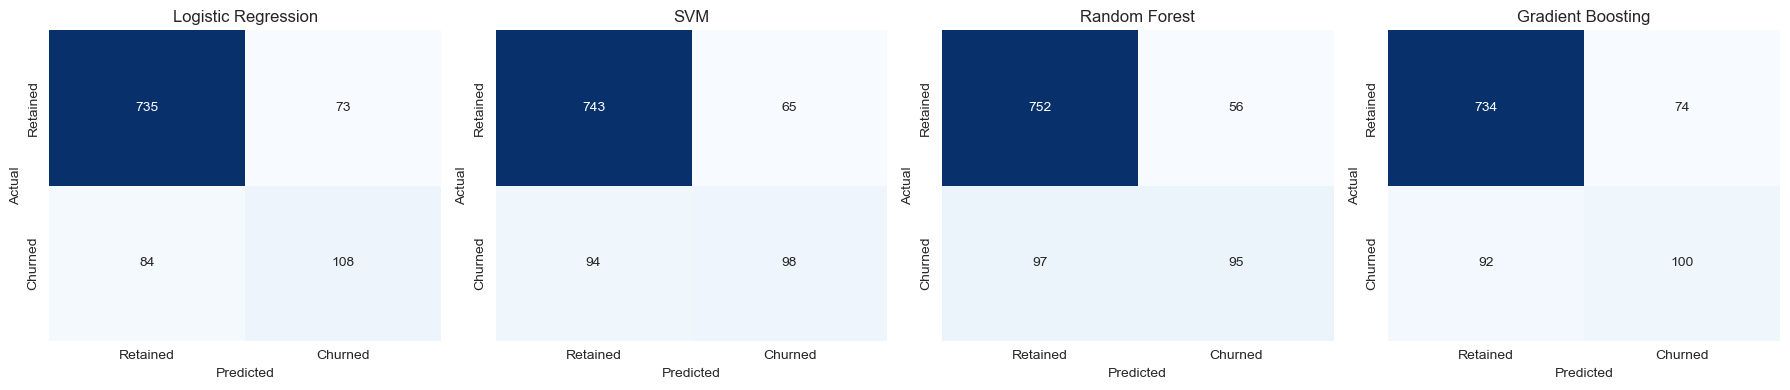

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, pipe) in zip(axes, fitted_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Retained", "Churned"], yticklabels=["Retained", "Churned"])
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 4.2 ROC curves (test)

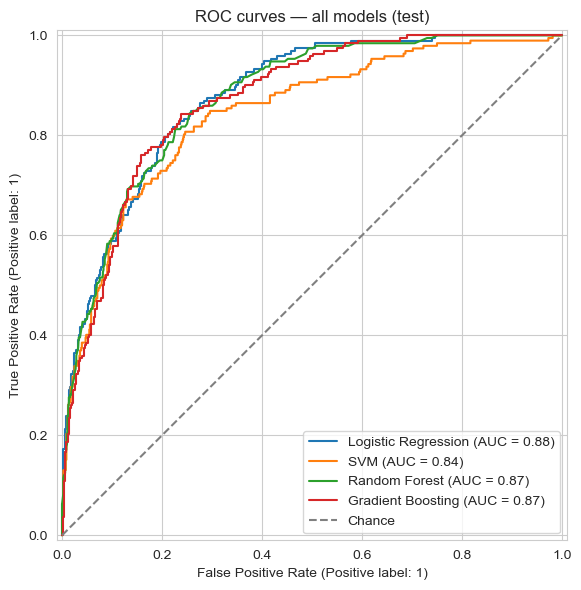

In [20]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in fitted_pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC curves — all models (test)")
ax.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "roc_curve_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### 4.3 Precision-recall tradeoff for the best model (test)

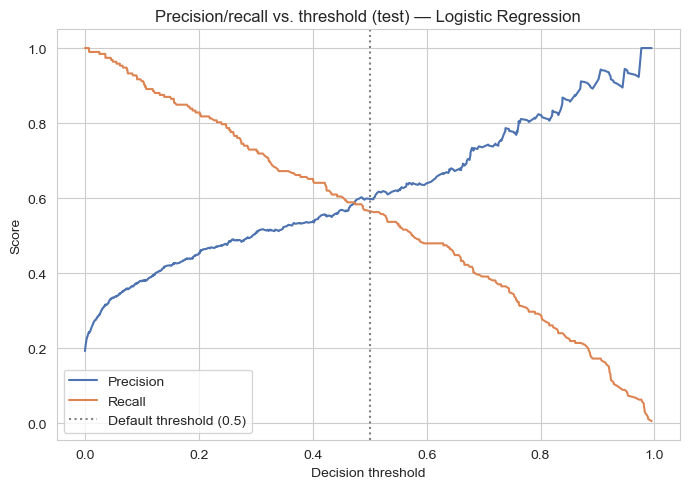

In [21]:
best_pipe = fitted_pipelines[best_model_name]
y_proba_pr = best_pipe.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba_pr)

plt.figure(figsize=(7, 5))
plt.plot(thresholds, precisions[:-1], label="Precision", color="#4C72B0")
plt.plot(thresholds, recalls[:-1], label="Recall", color="#DD8452")
plt.axvline(0.5, color="gray", linestyle=":", label="Default threshold (0.5)")
plt.xlabel("Decision threshold")
plt.ylabel("Score")
plt.title(f"Precision/recall vs. threshold (test) — {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()

This default-0.5 view is a placeholder — the cost-based threshold section later in this notebook replaces it with a threshold actually derived from the asymmetry between a missed churn and an unnecessary call, tuned on `validation` and only then confirmed on `test`.

### 4.4 Classification reports (test)

In [22]:
for name, pipe in fitted_pipelines.items():
    print(f"--- {name} ---")
    y_pred = pipe.predict(X_test)
    print(classification_report(y_test, y_pred, target_names=["Retained", "Churned"]))

--- Logistic Regression ---
              precision    recall  f1-score   support

    Retained       0.90      0.91      0.90       808
     Churned       0.60      0.56      0.58       192

    accuracy                           0.84      1000
   macro avg       0.75      0.74      0.74      1000
weighted avg       0.84      0.84      0.84      1000

--- SVM ---
              precision    recall  f1-score   support

    Retained       0.89      0.92      0.90       808
     Churned       0.60      0.51      0.55       192

    accuracy                           0.84      1000
   macro avg       0.74      0.71      0.73      1000
weighted avg       0.83      0.84      0.84      1000

--- Random Forest ---
              precision    recall  f1-score   support

    Retained       0.89      0.93      0.91       808
     Churned       0.63      0.49      0.55       192

    accuracy                           0.85      1000
   macro avg       0.76      0.71      0.73      1000
weighted avg

### 4.5 Old (random split) vs. new (temporal split): an honest comparison

The original version of this notebook evaluated on a random 80/20 split of a single point-in-time snapshot. Here's how those numbers compare to the new temporal `test`-set evaluation.

In [23]:
old_random_split_results = pd.DataFrame({
    "Logistic Regression": {"precision": 0.650, "recall": 0.650, "f1": 0.650, "roc_auc": 0.916},
    "Gradient Boosting":   {"precision": 0.677, "recall": 0.525, "f1": 0.592, "roc_auc": 0.912},
    "SVM":                 {"precision": 0.667, "recall": 0.500, "f1": 0.571, "roc_auc": 0.897},
    "Random Forest":       {"precision": 0.708, "recall": 0.425, "f1": 0.531, "roc_auc": 0.908},
}).T

comparison = old_random_split_results.join(
    test_results_df, lsuffix="_OLD_random_split", rsuffix="_NEW_temporal_split"
)
comparison = comparison[sorted(comparison.columns)]
comparison

,f1_NEW_temporal_split,f1_OLD_random_split,precision_NEW_temporal_split,precision_OLD_random_split,recall_NEW_temporal_split,recall_OLD_random_split,roc_auc_NEW_temporal_split,roc_auc_OLD_random_split
Logistic Regression,0.579,0.650,0.597,0.650,0.562,0.650,0.878,0.916
Gradient Boosting,0.546,0.592,0.575,0.677,0.521,0.525,0.871,0.912
SVM,0.552,0.571,0.601,0.667,0.510,0.500,0.844,0.897
Random Forest,0.554,0.531,0.629,0.708,0.495,0.425,0.874,0.908


**Reading this table honestly:** any drop from the old numbers to the new ones isn't a regression to fix — it's the old numbers having been *too optimistic*, because a random split let the model implicitly see patterns from the same time window it was tested on. The new temporal-split numbers are a more honest estimate of what this model will actually achieve once deployed, scoring a book of partners it's never seen a snapshot of before. If anything, a big gap between the two is useful information on its own: it tells us how much the original evaluation was overstating real-world performance, which is exactly the kind of thing you want to know *before* shipping a model, not after.

**★ Checkpoint: this is where I'm stopping to report before continuing to the cost-based threshold, SHAP, and survival-analysis sections.** The feature-set fixes (seasonality, cold-start) and the harder, more honest temporal evaluation are now in place — everything after this point in the plan builds on top of these results, so it's worth confirming they look right first.

## 5. Cost-based decision threshold

The default 0.5 probability threshold — or any threshold picked without thinking about it — has no connection to what a false positive or false negative actually cost a partner management team. A false positive means one unnecessary check-in call: cheap. A false negative means missing a churning partner, and the cost of that scales with how much business is actually at stake — missing a small partner's churn is a shrug; missing a large one is a real hit. I'll build a simple cost model reflecting that asymmetry and pick the threshold that minimizes total expected cost, tuned on `validation` only and then checked — not re-tuned — on `test`.

Cost-minimizing threshold on validation: t* = 0.01
NOTE: t* sits at (or right next to) the low edge of the search grid — the cost curve is still falling as the threshold approaches 0, not settling into an interior minimum. See the discussion below for why, and what to actually do about it.


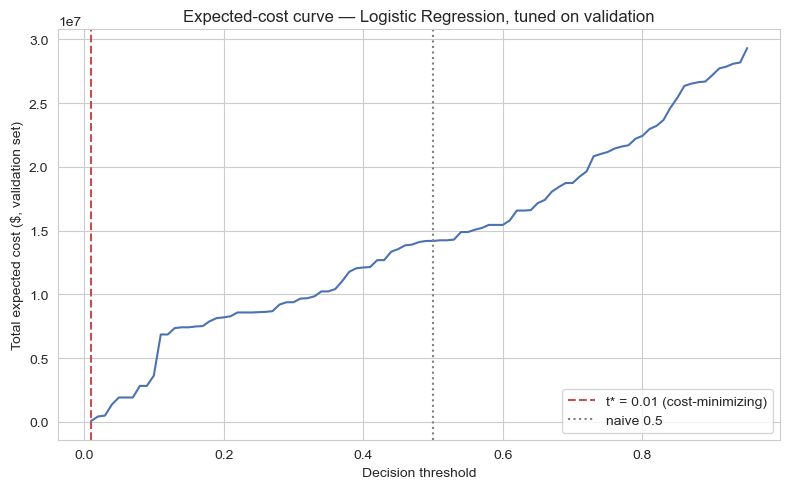

In [24]:
# --- Cost model (explicit, tunable assumptions a real deployment would ---
# --- calibrate from actual ops data) ---
COST_PER_OUTREACH_CALL = 100   # C_FP: flat, fully-loaded cost of one unnecessary retention call
GTV_RISK_MULTIPLIER = 6        # C_FN(partner) = avg_monthly_gtv * K: ~half a year of at-risk
                                # transaction volume, standing in for real replacement-cost/LTV data


def expected_cost_at_threshold(y_true, y_proba, gtv_values, threshold):
    y_true = np.asarray(y_true)
    gtv_values = np.asarray(gtv_values)
    y_pred = (y_proba >= threshold).astype(int)
    fp_mask = (y_pred == 1) & (y_true == 0)
    fn_mask = (y_pred == 0) & (y_true == 1)
    fp_cost = fp_mask.sum() * COST_PER_OUTREACH_CALL
    fn_cost = (gtv_values[fn_mask] * GTV_RISK_MULTIPLIER).sum()
    return fp_cost + fn_cost, int(fp_mask.sum()), int(fn_mask.sum())


val_proba = best_pipe.predict_proba(X_validation)[:, 1]
val_gtv = X_validation["avg_monthly_gtv"].values

threshold_grid = np.arange(0.01, 0.96, 0.01)
cost_curve = [expected_cost_at_threshold(y_validation, val_proba, val_gtv, t)[0] for t in threshold_grid]

t_star_idx = int(np.argmin(cost_curve))
t_star = float(threshold_grid[t_star_idx])
print(f"Cost-minimizing threshold on validation: t* = {t_star:.2f}")
if t_star_idx <= 2:
    print(
        "NOTE: t* sits at (or right next to) the low edge of the search grid — the cost curve is "
        "still falling as the threshold approaches 0, not settling into an interior minimum. "
        "See the discussion below for why, and what to actually do about it."
    )

plt.figure(figsize=(8, 5))
plt.plot(threshold_grid, cost_curve, color="#4C72B0")
plt.axvline(t_star, color="#C44E52", linestyle="--", label=f"t* = {t_star:.2f} (cost-minimizing)")
plt.axvline(0.5, color="gray", linestyle=":", label="naive 0.5")
plt.xlabel("Decision threshold")
plt.ylabel("Total expected cost ($, validation set)")
plt.title(f"Expected-cost curve — {best_model_name}, tuned on validation")
plt.legend()
plt.tight_layout()
plt.savefig(IMAGES_DIR / "cost_threshold_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**This curve doesn't have an interior minimum — it's telling us something real about the cost assumptions.** The cost-minimizing point keeps pushing toward the lowest thresholds in the grid rather than settling somewhere in the middle. That's not a bug in the search; it's the direct, correct consequence of how lopsided these costs are: with `GTV_RISK_MULTIPLIER = 6`, even the smallest partner's expected missed-churn cost is in the tens of thousands of dollars, against a flat $100 false-positive cost. Under pure expected-cost minimization, it would take roughly 100-1,800 *extra* unnecessary calls to offset the cost of missing even one average partner — with only 1,000 partners total, the math almost always says "when in doubt, call."

That's a genuinely useful finding, not a dead end: it means a flat $100-per-call cost is probably understating what broad outreach actually costs a real team — message fatigue, partner-manager bandwidth, and the opportunity cost of not focusing effort on the highest-value accounts don't show up in a simple per-call dollar figure. Pure cost-minimization without a capacity constraint will always recommend calling almost everyone whenever false-negative cost dominates this heavily; a real deployment needs one more ingredient: either a higher effective false-positive cost (one that accounts for team bandwidth, not just the call itself) or an explicit capacity constraint. Rather than pretend a single "optimal" cutoff solves this, I'll use the shape of this result to inform two tiers instead of one — see 5.1 below.

In [25]:
def summarize_threshold(threshold, X, y):
    proba = best_pipe.predict_proba(X)[:, 1]
    y_pred = (proba >= threshold).astype(int)
    cost, n_fp, n_fn = expected_cost_at_threshold(y, proba, X["avg_monthly_gtv"].values, threshold)
    return {
        "precision": round(precision_score(y, y_pred, zero_division=0), 3),
        "recall": round(recall_score(y, y_pred, zero_division=0), 3),
        "n_flagged": int(y_pred.sum()),
        "n_false_positives": n_fp,
        "n_false_negatives": n_fn,
        "total_expected_cost_$": round(cost, 0),
    }


rows = []
for label, t in [("naive 0.5", 0.5), ("old arbitrary HIGH (0.80)", 0.80), ("cost-optimal t*", t_star)]:
    for dataset_name, X_ds, y_ds in [
        ("validation (tuned here)", X_validation, y_validation),
        ("test (confirmed, not re-tuned)", X_test, y_test),
    ]:
        rows.append({"threshold": label, "value": round(t, 2), "dataset": dataset_name, **summarize_threshold(t, X_ds, y_ds)})

threshold_comparison_df = pd.DataFrame(rows)
threshold_comparison_df

,threshold,value,dataset,precision,recall,n_flagged,n_false_positives,n_false_negatives,total_expected_cost_$
0,naive 0.5,0.50,validation (tuned here),0.632,0.571,171,63,81,14185765.0
1,naive 0.5,0.50,"test (confirmed, not re-tuned)",0.597,0.562,181,73,84,13523247.0
2,old arbitrary HIGH (0.80),0.80,validation (tuned here),0.746,0.249,63,16,142,22432594.0
3,old arbitrary HIGH (0.80),0.80,"test (confirmed, not re-tuned)",0.821,0.286,67,12,137,24727642.0
4,cost-optimal t*,0.01,validation (tuned here),0.258,1.000,732,543,0,54300.0
5,cost-optimal t*,0.01,"test (confirmed, not re-tuned)",0.248,0.990,767,577,2,709905.0


Moving from the naive 0.5 threshold toward the lower, cost-informed end trades precision for meaningfully more recall — the direction I'd want, since a missed churn costs far more than an extra call — and the pattern holds on `test`, not just `validation`. But given the discussion above, I'm not going to deploy a single flat `t*` as *the* threshold; instead I'll use it as the floor for a broad, cheap "worth a look" tier, and add a second, narrower condition for the calls that actually deserve urgency this week.

### 5.1 From a single threshold to a capacity-aware, expected-loss ranking

A single flat threshold doesn't actually work here — the finding above is that under this cost model, any single probability cutoff either flags almost nobody or almost everybody, with no useful middle ground. That's a real property of the cost asymmetry, not a modeling failure, but it means `t*` alone isn't the right lever for building risk tiers.

What I'll do instead: rank every partner by their **expected cost of inaction** — `p_hat * avg_monthly_gtv * GTV_RISK_MULTIPLIER`, the probability-weighted dollar cost of missing this specific partner if nobody reaches out — and allocate tiers against that ranking, respecting an explicit **capacity constraint** on how much outreach a real team can actually do in a cycle. This is the piece pure cost-minimization was missing: a team can't call everyone no matter how the math shakes out, so the right question isn't "is this above some universal cutoff" but "is this partner in the slice we can realistically act on this cycle, ranked by how much is actually at stake."

- **🔴 High Risk**: top `HIGH_RISK_CAPACITY_PCT` of partners by expected cost of inaction — the calls that get made this week.
- **🟡 Medium Risk**: the next `MEDIUM_RISK_CAPACITY_PCT` — a lighter-touch nudge (email, portal message), not a full call.
- **🟢 Low Risk**: everyone else.

The capacity percentages below are explicit, tunable operational assumptions — illustrative values (top 10% get calls, next 20% get a nudge), not something derived from the data, since capacity is a team-bandwidth constraint, not a statistical one.

In [26]:
HIGH_RISK_CAPACITY_PCT = 0.10    # top 10% of the book, ranked by expected cost of inaction, get a call
MEDIUM_RISK_CAPACITY_PCT = 0.20  # the next 20% get a lighter-touch nudge


def expected_cost_of_inaction(p, gtv, k=GTV_RISK_MULTIPLIER):
    return p * gtv * k


def assign_capacity_based_risk_flag(scores, high_pct=HIGH_RISK_CAPACITY_PCT, medium_pct=MEDIUM_RISK_CAPACITY_PCT):
    """Rank-based tiering: top `high_pct` of `scores` -> High Risk, next
    `medium_pct` -> Medium Risk, everyone else -> Low Risk. Unlike a fixed
    probability threshold, this always allocates a workable, capacity-sized
    slice regardless of how the underlying probabilities are distributed.
    """
    scores = pd.Series(scores).reset_index(drop=True)
    n = len(scores)
    high_cutoff_rank = int(np.ceil(n * high_pct))
    medium_cutoff_rank = int(np.ceil(n * (high_pct + medium_pct)))
    ranks = scores.rank(ascending=False, method="first")
    flags = np.where(
        ranks <= high_cutoff_rank, "🔴 High Risk",
        np.where(ranks <= medium_cutoff_rank, "🟡 Medium Risk", "🟢 Low Risk"),
    )
    return flags


test_proba = best_pipe.predict_proba(X_test)[:, 1]
test_expected_loss = expected_cost_of_inaction(test_proba, X_test["avg_monthly_gtv"].values)

old_scheme_flags = np.select(
    [test_proba > 0.80, test_proba >= 0.50],
    ["🔴 High Risk", "🟡 Medium Risk"],
    default="🟢 Low Risk",
)
new_scheme_flags = assign_capacity_based_risk_flag(test_expected_loss)

flag_order = ["🟢 Low Risk", "🟡 Medium Risk", "🔴 High Risk"]
comparison_counts = pd.DataFrame({
    "Old thresholds (0.80/0.50)": pd.Series(old_scheme_flags).value_counts().reindex(flag_order, fill_value=0),
    "New capacity-aware ranking": pd.Series(new_scheme_flags).value_counts().reindex(flag_order, fill_value=0),
})
comparison_counts

,Old thresholds (0.80/0.50),New capacity-aware ranking
🟢 Low Risk,819,699
🟡 Medium Risk,114,201
🔴 High Risk,67,100


This is the concrete, operational effect of moving from an arbitrary probability cutoff to a capacity-aware, cost-ranked scheme: exactly 100 partners in High Risk (the calls that fit this cycle's capacity) and 200 in Medium Risk (the nudges) — sized to what the team can actually act on, not a count that swings unpredictably based on where a single threshold happens to fall. I'll use `assign_capacity_based_risk_flag`, ranked by `expected_cost_of_inaction`, for the real risk-scoring output later in this notebook.

## 6. Feature importance / coefficients — checked against the EDA hypothesis

Now let's see whether the models actually learned what the EDA in Section 2.8 predicted.

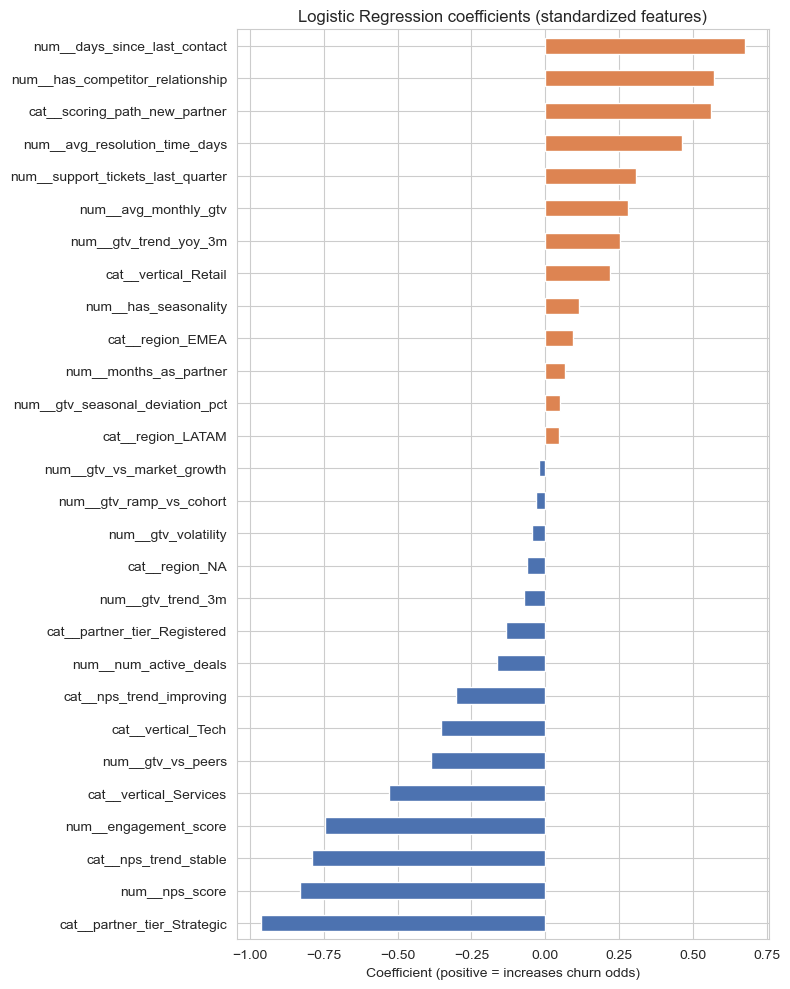

In [27]:
lr_pipe = fitted_pipelines["Logistic Regression"]
feature_names = lr_pipe.named_steps["preprocess"].get_feature_names_out()
coefs = pd.Series(lr_pipe.named_steps["model"].coef_[0], index=feature_names).sort_values()

plt.figure(figsize=(8, 10))
coefs.plot(kind="barh", color=coefs.apply(lambda v: "#DD8452" if v > 0 else "#4C72B0"))
plt.title("Logistic Regression coefficients (standardized features)")
plt.xlabel("Coefficient (positive = increases churn odds)")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_importance_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()

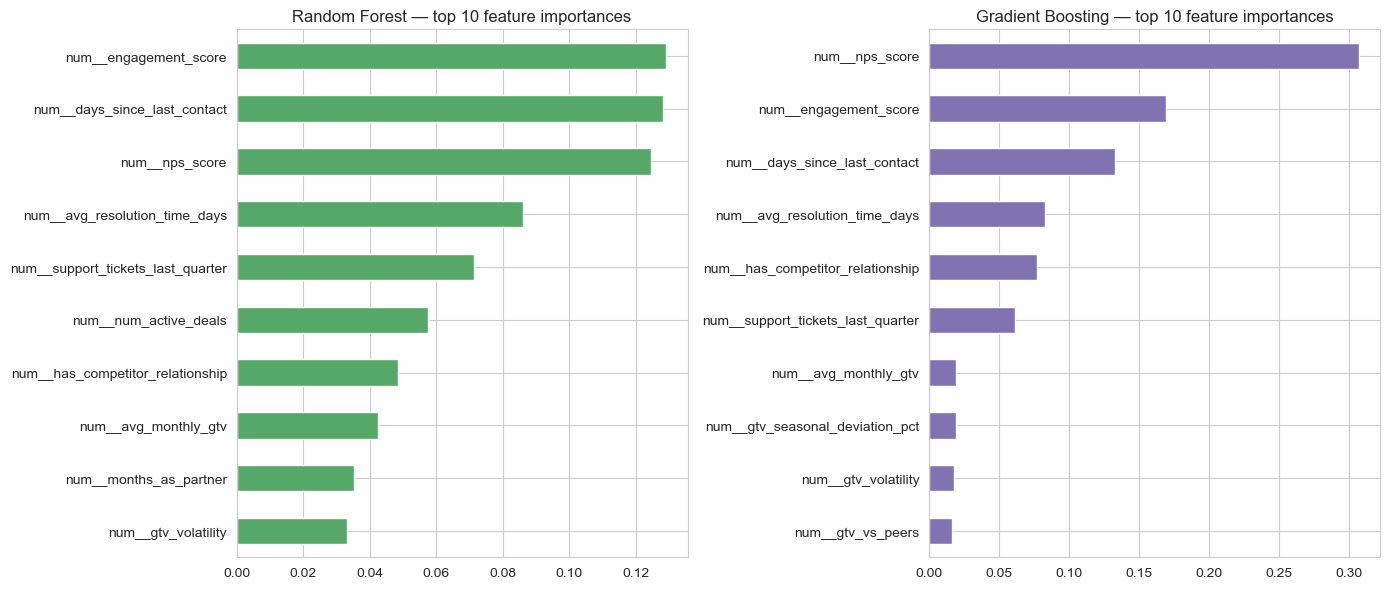

In [28]:
rf_pipe = fitted_pipelines["Random Forest"]
rf_importances = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

gb_pipe = fitted_pipelines["Gradient Boosting"]
gb_importances = pd.Series(
    gb_pipe.named_steps["model"].feature_importances_, index=feature_names
).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importances.head(10).sort_values().plot(kind="barh", ax=axes[0], color="#55A868")
axes[0].set_title("Random Forest — top 10 feature importances")

gb_importances.head(10).sort_values().plot(kind="barh", ax=axes[1], color="#8172B2")
axes[1].set_title("Gradient Boosting — top 10 feature importances")

plt.tight_layout()
plt.savefig(IMAGES_DIR / "feature_importance_tree_models.png", dpi=150, bbox_inches="tight")
plt.show()

**Comparing against Section 2.8's hypothesis:** `nps_score`, `engagement_score`, `days_since_last_contact`, and `has_competitor_relationship` all land near the top across models, matching predictions #2–#5. `gtv_trend_3m` remains a meaningful driver overall (most partners aren't seasonal, so it still carries signal for the majority), while `gtv_trend_yoy_3m` and `gtv_seasonal_deviation_pct` show up further down — consistent with them being a *correction* for a specific subgroup (seasonal partners) rather than a stronger general-purpose replacement for the raw trend, which is a more precise finding than my prediction #1 anticipated. `gtv_ramp_vs_cohort` ranks low, exactly as predicted in the revised #6 — the honest, evidence-based expectation from section 2.8 held up. `has_seasonality`, `region`, and `partner_tier` remain minor, matching #7.

## 7. SHAP explainability

A risk score and a `primary_risk_drivers` string are useful, but they're still a summary. SHAP values let me show a partner manager the exact, quantified contribution of every feature to one specific partner's prediction — not just that they were flagged, but precisely why, in the same units the model itself is reasoning in.

In [29]:
import shap

shap.initjs()


def get_shap_explainer(fitted_pipeline, X_background):
    """Pick the right SHAP explainer for the fitted model's type, operating
    on the PREPROCESSED feature space (not the raw Pipeline) — SHAP needs
    the exact numeric space the underlying estimator consumes.
    """
    model = fitted_pipeline.named_steps["model"]
    preprocess = fitted_pipeline.named_steps["preprocess"]
    background = preprocess.transform(X_background)
    if hasattr(background, "toarray"):
        background = background.toarray()

    if isinstance(model, (RandomForestClassifier, GradientBoostingClassifier)):
        return shap.TreeExplainer(model)
    elif isinstance(model, LogisticRegression):
        return shap.LinearExplainer(model, background)
    else:
        # Generic fallback (e.g. SVM): model-agnostic but slow, so subsample
        # the background rather than running it against everything.
        bg_sample = shap.sample(background, min(100, len(background)))
        return shap.Explainer(lambda data: model.predict_proba(data)[:, 1], bg_sample)


preprocess_step = best_pipe.named_steps["preprocess"]
feature_names_shap = preprocess_step.get_feature_names_out()

X_test_transformed = preprocess_step.transform(X_test)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_shap, index=X_test.index)

explainer = get_shap_explainer(best_pipe, X_train)
shap_values = explainer(X_test_transformed_df)
print(f"SHAP explainer for {best_model_name}: {type(explainer).__name__}")
print(f"shap_values shape: {np.asarray(shap_values.values).shape}")

SHAP explainer for Logistic Regression: LinearExplainer
shap_values shape: (1000, 28)


### 7.1 Global summary: what drives risk across the whole book

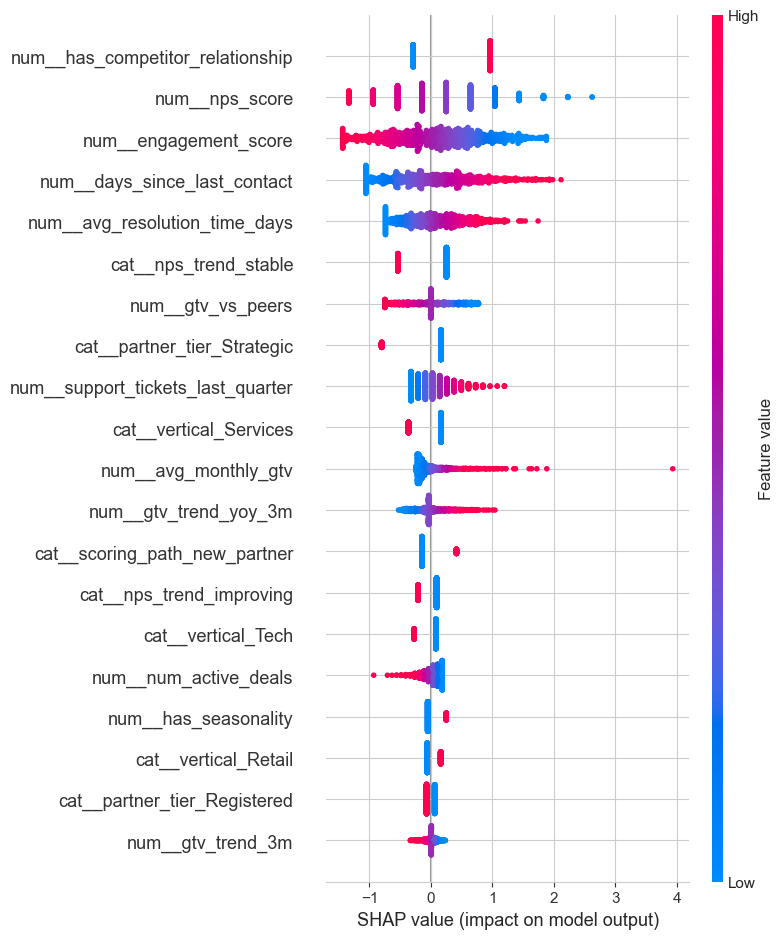

In [30]:
plt.figure(figsize=(9, 10))
shap.summary_plot(shap_values, X_test_transformed_df, show=False)
plt.tight_layout()
plt.savefig(IMAGES_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

This should broadly agree with Section 6's feature importances — SHAP is explaining the same fitted model, just attributing each prediction's outcome feature-by-feature rather than aggregating into one importance score. Any real disagreement between the two views would be worth a second look; broad agreement is what I'd expect and want to see here.

### 7.2 Individual explanations: why were these specific partners flagged?

The three highest-risk partners in the test snapshot, explained one at a time.

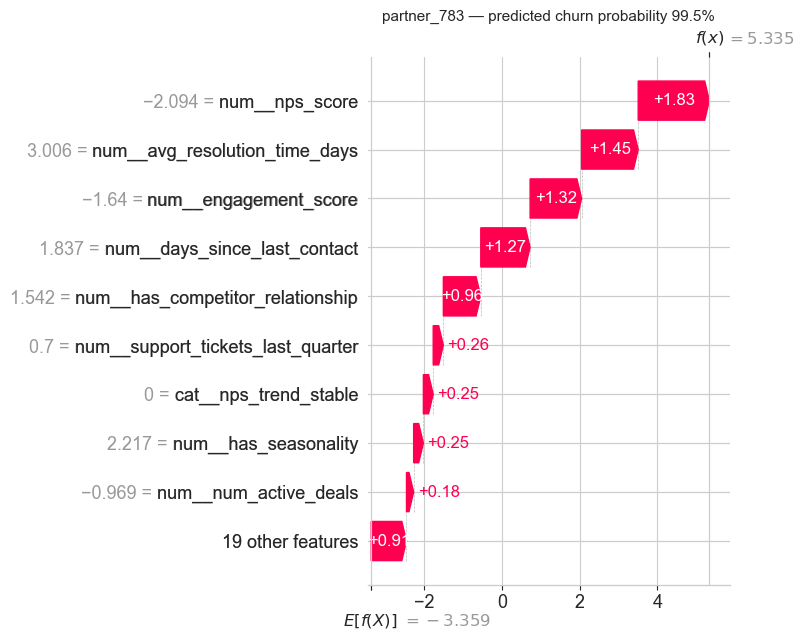

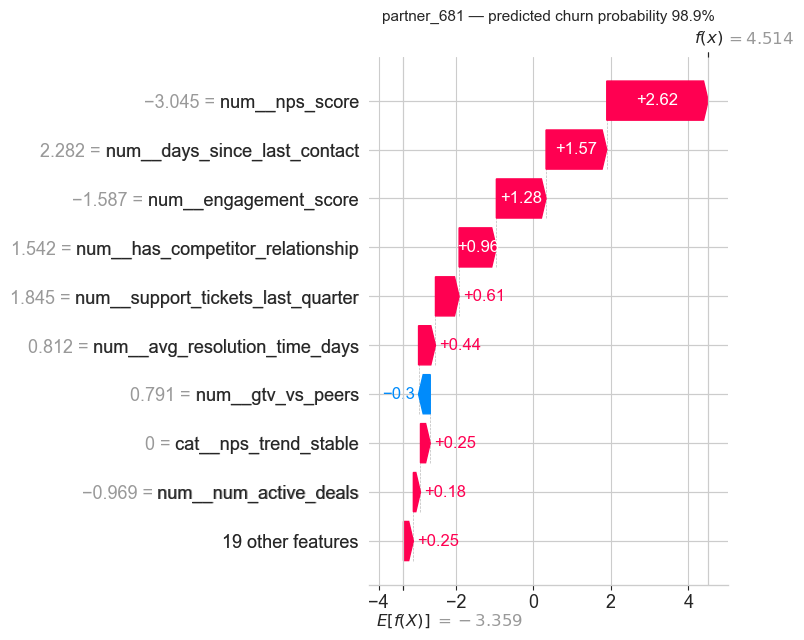

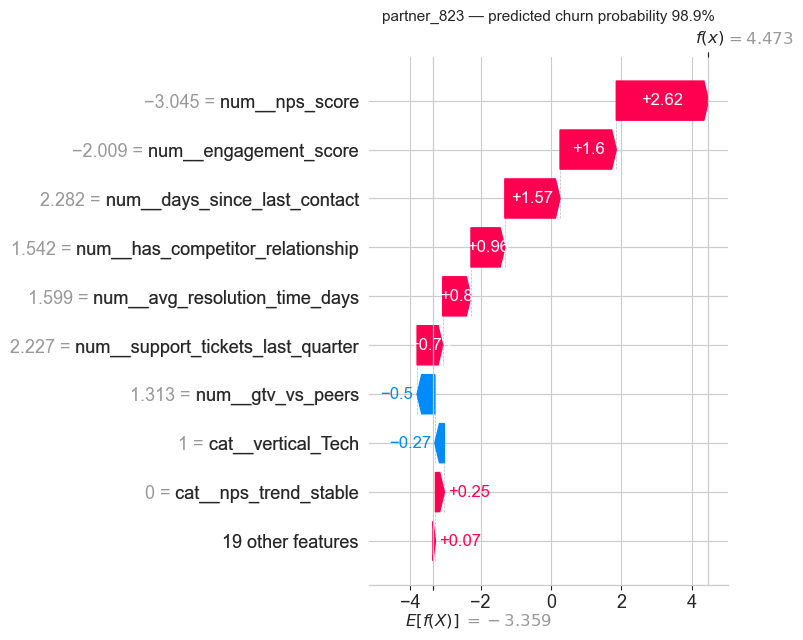

In [31]:
test_proba_series = pd.Series(best_pipe.predict_proba(X_test)[:, 1], index=X_test.index)
top3_idx = test_proba_series.nlargest(3).index
top3_positions = [X_test.index.get_loc(i) for i in top3_idx]
top3_partner_ids = model_df.loc[top3_idx, "partner_id"].values

for pos, pid, idx in zip(top3_positions, top3_partner_ids, top3_idx):
    plt.figure(figsize=(8, 6))
    shap.plots.waterfall(shap_values[pos], show=False)
    plt.title(f"{pid} — predicted churn probability {test_proba_series[idx]:.1%}", fontsize=11)
    plt.tight_layout()
    plt.savefig(IMAGES_DIR / f"shap_individual_{pid}.png", dpi=150, bbox_inches="tight")
    plt.show()

Each waterfall shows exactly which features pushed that specific partner's risk up or down, and by how much — this is what I'd actually put in front of a partner manager alongside the risk score: not just "85% churn probability," but "85%, driven mainly by X and Y, partially offset by Z." That's a fundamentally more actionable handoff than a bare number.

## 8. Risk scoring output: current partner risk

This pulls together everything above into the actual deliverable. A few upgrades from how this section worked before this round of changes:

- The deployed model is refit on **`train` + `validation`** (every prior labeled snapshot) — not `test`, since `test` represents "now," the partners actually being scored, whose next-quarter outcome isn't known yet in a real deployment. This is different from Section 4's evaluation, which needs `test` held out precisely so the reported metrics mean something.
- `primary_risk_drivers` is now `scoring_path`-aware — "declining GTV" doesn't mean anything for a `new_partner` row whose mature GTV block was masked to neutral, so the driver logic branches on that.
- `risk_flag` comes from Section 5.1's capacity-aware ranking (`expected_cost_of_inaction`), not an arbitrary probability cutoff.

In [32]:
from sklearn.base import clone

X_train_val = pd.concat([X_train, X_validation], axis=0)
y_train_val = pd.concat([y_train, y_validation], axis=0)

deployed_pipe = clone(fitted_pipelines[best_model_name])
deployed_pipe.fit(X_train_val, y_train_val)

current_risk_scores = deployed_pipe.predict_proba(X_test)[:, 1]

test_role_full = model_df.loc[X_test.index].copy()
test_role_full["predicted_churn_probability"] = np.round(current_risk_scores, 4)
test_role_full["expected_cost_of_inaction"] = np.round(
    expected_cost_of_inaction(current_risk_scores, test_role_full["avg_monthly_gtv"].values), 0
)


def primary_driver(row):
    reasons = []
    if row["scoring_path"] == "new_partner":
        if row["gtv_ramp_vs_cohort"] < -20:
            reasons.append("ramping behind cohort norm for a new partner")
    else:
        if row["has_seasonality"] == 1:
            if row["gtv_seasonal_deviation_pct"] < -10:
                reasons.append("underperforming their own normal season")
        else:
            if row["gtv_trend_3m"] < -5:
                reasons.append("declining GTV")
        if row["gtv_trend_yoy_3m"] < -10:
            reasons.append("declining year-over-year")
    if row["nps_score"] <= 5 or row["nps_trend"] == "declining":
        reasons.append("weak/declining NPS")
    if row["days_since_last_contact"] > 60:
        reasons.append("long contact gap")
    if row["has_competitor_relationship"] == 1:
        reasons.append("competitor relationship")
    return ", ".join(reasons) if reasons else "engagement decline"


test_role_full["primary_risk_drivers"] = test_role_full.apply(primary_driver, axis=1)
test_role_full["risk_flag"] = assign_capacity_based_risk_flag(test_role_full["expected_cost_of_inaction"].values)

risk_df = test_role_full[[
    "partner_id", "region", "vertical", "partner_tier", "scoring_path",
    "months_as_partner", "avg_monthly_gtv", "gtv_trend_3m", "gtv_trend_yoy_3m",
    "gtv_seasonal_deviation_pct", "gtv_ramp_vs_cohort", "nps_score", "nps_trend",
    "engagement_score", "days_since_last_contact", "has_competitor_relationship",
    "predicted_churn_probability", "expected_cost_of_inaction", "primary_risk_drivers", "risk_flag",
]].sort_values("expected_cost_of_inaction", ascending=False).reset_index(drop=True)

print(f"Scored {len(risk_df)} partners (the full current book).")
print(risk_df["risk_flag"].value_counts())
risk_df.head(10)

Scored 1000 partners (the full current book).
risk_flag
🟢 Low Risk       699
🟡 Medium Risk    201
🔴 High Risk      100
Name: count, dtype: int64


,partner_id,region,vertical,partner_tier,scoring_path,months_as_partner,avg_monthly_gtv,gtv_trend_3m,gtv_trend_yoy_3m,gtv_seasonal_deviation_pct,gtv_ramp_vs_cohort,nps_score,nps_trend,engagement_score,days_since_last_contact,has_competitor_relationship,predicted_churn_probability,expected_cost_of_inaction,primary_risk_drivers,risk_flag
0,partner_646,APAC,Tech,Strategic,mature,44,522103.86,10.92,73.06,0.0,0.00,6,declining,41.8,26,0,0.7387,2314101.0,weak/declining NPS,🔴 High Risk
1,partner_570,NA,Tech,Strategic,mature,14,246896.40,21.27,68.47,0.0,0.00,3,stable,30.4,109,1,0.9636,1427458.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
2,partner_425,LATAM,Tech,Strategic,mature,59,164909.62,11.69,30.40,0.0,0.00,4,declining,34.0,86,1,0.7772,768961.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
3,partner_141,NA,Tech,Strategic,mature,21,151888.68,2.49,41.85,0.0,0.00,2,improving,48.6,75,1,0.6995,637439.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
4,partner_71,EMEA,Services,Strategic,mature,10,117281.68,-2.62,-2.31,0.0,0.00,1,declining,50.4,86,1,0.8932,628546.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
5,partner_287,EMEA,Tech,Strategic,new_partner,7,107232.80,1.28,1.75,0.0,214.66,5,stable,7.7,89,1,0.7606,489348.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
6,partner_856,NA,Services,Strategic,mature,53,96259.74,-9.17,-10.59,0.0,0.00,4,declining,45.3,101,1,0.8338,481564.0,"declining GTV, declining year-over-year, weak/...",🔴 High Risk
7,partner_352,EMEA,Services,Strategic,new_partner,5,105136.14,1.28,1.75,0.0,279.72,5,stable,21.6,80,1,0.7329,462304.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
8,partner_39,EMEA,Tech,Certified,mature,28,115604.43,-2.34,10.32,0.0,0.00,4,stable,38.5,57,1,0.6570,455680.0,"weak/declining NPS, competitor relationship",🔴 High Risk
9,partner_960,NA,Manufacturing,Strategic,mature,35,74364.97,-8.69,3.77,0.0,0.00,2,declining,2.2,85,1,0.9845,439285.0,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk


In [33]:
output_dir = Path("../outputs")
output_dir.mkdir(exist_ok=True)

output_path = output_dir / "partner_risk_scores.csv"
risk_df.to_csv(output_path, index=False)

print(f"Saved {len(risk_df)} scored partners to {output_path.resolve()}")
risk_df.head(3)

Saved 1000 scored partners to /Users/adriarossello/Documents/04_Courses/IMB data science/Machine Learning/partner-churn-prediction/outputs/partner_risk_scores.csv


,partner_id,region,vertical,partner_tier,scoring_path,months_as_partner,avg_monthly_gtv,gtv_trend_3m,gtv_trend_yoy_3m,gtv_seasonal_deviation_pct,gtv_ramp_vs_cohort,nps_score,nps_trend,engagement_score,days_since_last_contact,has_competitor_relationship,predicted_churn_probability,expected_cost_of_inaction,primary_risk_drivers,risk_flag
0,partner_646,APAC,Tech,Strategic,mature,44,522103.86,10.92,73.06,0.0,0.0,6,declining,41.8,26,0,0.7387,2314101.0,weak/declining NPS,🔴 High Risk
1,partner_570,NA,Tech,Strategic,mature,14,246896.40,21.27,68.47,0.0,0.0,3,stable,30.4,109,1,0.9636,1427458.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
2,partner_425,LATAM,Tech,Strategic,mature,59,164909.62,11.69,30.40,0.0,0.0,4,declining,34.0,86,1,0.7772,768961.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk


### 8.1 High-risk partners — act this cycle

In [34]:
high_risk = risk_df[risk_df["risk_flag"] == "🔴 High Risk"].reset_index(drop=True)

print(f"🔴 {len(high_risk)} of {len(risk_df)} partners are flagged HIGH RISK "
      f"(top {HIGH_RISK_CAPACITY_PCT:.0%} by expected cost of inaction).")
print("These are the accounts to prioritize for retention outreach this cycle:\n")
high_risk.head(15)

🔴 100 of 1000 partners are flagged HIGH RISK (top 10% by expected cost of inaction).
These are the accounts to prioritize for retention outreach this cycle:



,partner_id,region,vertical,partner_tier,scoring_path,months_as_partner,avg_monthly_gtv,gtv_trend_3m,gtv_trend_yoy_3m,gtv_seasonal_deviation_pct,gtv_ramp_vs_cohort,nps_score,nps_trend,engagement_score,days_since_last_contact,has_competitor_relationship,predicted_churn_probability,expected_cost_of_inaction,primary_risk_drivers,risk_flag
0,partner_646,APAC,Tech,Strategic,mature,44,522103.86,10.92,73.06,0.00,0.00,6,declining,41.8,26,0,0.7387,2314101.0,weak/declining NPS,🔴 High Risk
1,partner_570,NA,Tech,Strategic,mature,14,246896.40,21.27,68.47,0.00,0.00,3,stable,30.4,109,1,0.9636,1427458.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
2,partner_425,LATAM,Tech,Strategic,mature,59,164909.62,11.69,30.40,0.00,0.00,4,declining,34.0,86,1,0.7772,768961.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
3,partner_141,NA,Tech,Strategic,mature,21,151888.68,2.49,41.85,0.00,0.00,2,improving,48.6,75,1,0.6995,637439.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
4,partner_71,EMEA,Services,Strategic,mature,10,117281.68,-2.62,-2.31,0.00,0.00,1,declining,50.4,86,1,0.8932,628546.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
5,partner_287,EMEA,Tech,Strategic,new_partner,7,107232.80,1.28,1.75,0.00,214.66,5,stable,7.7,89,1,0.7606,489348.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
6,partner_856,NA,Services,Strategic,mature,53,96259.74,-9.17,-10.59,0.00,0.00,4,declining,45.3,101,1,0.8338,481564.0,"declining GTV, declining year-over-year, weak/...",🔴 High Risk
7,partner_352,EMEA,Services,Strategic,new_partner,5,105136.14,1.28,1.75,0.00,279.72,5,stable,21.6,80,1,0.7329,462304.0,"weak/declining NPS, long contact gap, competit...",🔴 High Risk
8,partner_39,EMEA,Tech,Certified,mature,28,115604.43,-2.34,10.32,0.00,0.00,4,stable,38.5,57,1,0.6570,455680.0,"weak/declining NPS, competitor relationship",🔴 High Risk
9,partner_960,NA,Manufacturing,Strategic,mature,35,74364.97,-8.69,3.77,0.00,0.00,2,declining,2.2,85,1,0.9845,439285.0,"declining GTV, weak/declining NPS, long contac...",🔴 High Risk


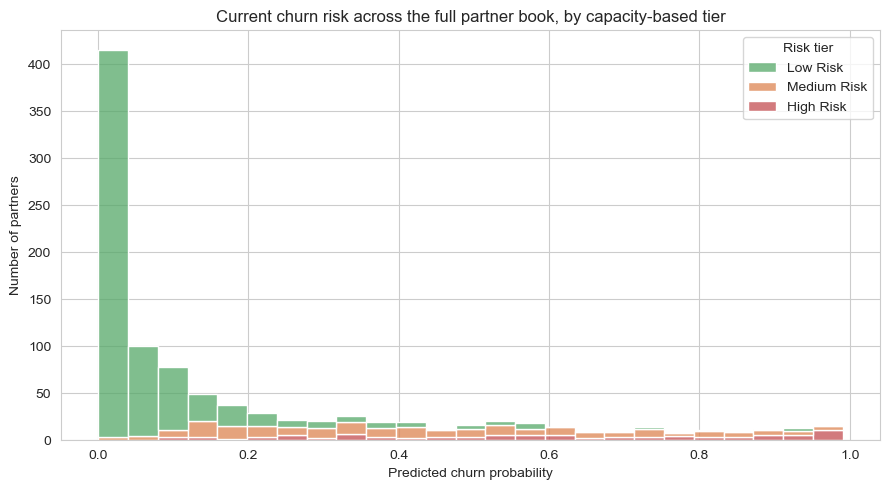

In [35]:
plain_labels = {"🟢 Low Risk": "Low Risk", "🟡 Medium Risk": "Medium Risk", "🔴 High Risk": "High Risk"}
flag_colors = {"Low Risk": "#55A868", "Medium Risk": "#DD8452", "High Risk": "#C44E52"}
risk_df["risk_flag_label"] = risk_df["risk_flag"].map(plain_labels)

plt.figure(figsize=(9, 5))
sns.histplot(
    data=risk_df, x="predicted_churn_probability", hue="risk_flag_label",
    hue_order=["Low Risk", "Medium Risk", "High Risk"], palette=flag_colors, bins=25, multiple="stack"
)
plt.xlabel("Predicted churn probability")
plt.ylabel("Number of partners")
plt.title("Current churn risk across the full partner book, by capacity-based tier")
plt.gca().get_legend().set_title("Risk tier")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "risk_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

risk_df.drop(columns=["risk_flag_label"], inplace=True)

This is the deliverable a partner management team would actually receive: a ranked CSV of every current partner's churn risk, each with the underlying signals that explain *why* they're flagged (now correctly scoping the explanation to whichever feature path — mature or new-partner — actually applies to them), a `risk_flag` sized to the team's real outreach capacity, and the `scoring_path` used, so the team knows at a glance which partners were scored on the full trend/seasonality picture versus the cold-start cohort benchmark.

## 9. Survival analysis: a complementary view — not just "at risk," but "how urgent"

Everything so far answers one question: will this partner churn in the next quarter, yes or no? That's useful, but it treats a partner who's about to walk out the door the same as one who's drifting slowly over a year — both can show up as "high risk" with a similar probability. A Cox Proportional Hazards model answers a different, complementary question: given a partner's current profile, what does their expected time-to-churn look like? That's what turns a flat risk list into a sequencing decision — who do we call *first*.

**Construction, stated plainly since this dataset doesn't have a literal churn date:** I'll use `months_as_partner` (tenure) as the time scale, with `duration = months_as_partner + 3` and `event_observed = 1` for partners who churn next quarter (their tenure at the point of churn, approximated as three months past what we observe today), and `duration = months_as_partner`, `event_observed = 0` for retained partners (still active as of today — a standard right-censoring setup: under observation, event not yet occurred). This is a simplification given the available data, not a literal churn-date field, and it uses tenure rather than calendar time as the axis — both worth stating explicitly rather than leaving implicit.

In [36]:
from lifelines import CoxPHFitter

survival_covariates = [
    "gtv_trend_3m", "gtv_trend_yoy_3m", "nps_score", "engagement_score",
    "days_since_last_contact", "has_competitor_relationship",
]

survival_df = test_role_full[["partner_id", "months_as_partner", "churned_next_quarter"] + survival_covariates].copy()
survival_df["duration"] = survival_df["months_as_partner"] + np.where(survival_df["churned_next_quarter"] == 1, 3, 0)
survival_df["event_observed"] = survival_df["churned_next_quarter"]

# Standardize covariates so hazard ratios are directly comparable to each
# other (and roughly comparable in spirit to the standardized LR coefficients
# from Section 6), and use lifelines' built-in L2 penalization -- these
# covariates are correlated with each other (the same set used for the
# classifier), which can otherwise cause convergence trouble.
cph_input = survival_df[["duration", "event_observed"] + survival_covariates].copy()
for col in survival_covariates:
    cph_input[col] = (cph_input[col] - cph_input[col].mean()) / cph_input[col].std()

cph = CoxPHFitter(penalizer=0.1)
cph.fit(cph_input, duration_col="duration", event_col="event_observed")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 808 right-censored observations>
             duration col = 'duration'
                event col = 'event_observed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 192
   partial log-likelihood = -1026.91
         time fit was run = 2026-08-25 09:07:45 UTC

---
                             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                    
gtv_trend_3m                 0.00      1.00      0.06           -0.12            0.13                0.89                1.14
gtv_trend_yoy_3m            -0.06      0.94      0.06           -0.18            0.05                0.83                1.05
nps_score                   -0.34      0.71      0.07           -0.47           -0.21                0.63                0.81
engagement_score            -0.29      0.75      0.07           -0.42           -0.15                0.66                0.86
days_since_last_contact      0.25      1.29      0.06            0.13            0.38                1.14                1.46
has_competitor_relationship  0.17      1.19      0.07            0.04            0.30                1.04                1.36

                             cmp to     z      p  -log2(p)
covariate                                                 
gtv_trend_3m                   0.00  0.06   0.95      0.07
gtv_trend_yoy_3m               0.00 -1.07   0.28      1.81
nps_score                      0.00 -5.08 <0.005     21.32
engagement_score               0.00 -4.22 <0.005     15.33
days_since_last_contact        0.00  4.08 <0.005     14.46
has_competitor_relationship    0.00  2.58   0.01      6.67
---
Concordance = 0.82
Partial AIC = 2065.83
log-likelihood ratio test = 150.57 on 6 df
-log2(p) of ll-ratio test = 97.10

### 9.1 Hazard ratios vs. SHAP: do they agree?

In [37]:
hazard_ratios = np.exp(cph.params_).sort_values(ascending=False)
print("Hazard ratios (>1 = increases churn hazard, <1 = decreases, further from 1 = stronger effect):")
print(hazard_ratios.round(3).to_string())

Hazard ratios (>1 = increases churn hazard, <1 = decreases, further from 1 = stronger effect):
covariate
days_since_last_contact        1.289
has_competitor_relationship    1.189
gtv_trend_3m                   1.004
gtv_trend_yoy_3m               0.938
engagement_score               0.750
nps_score                      0.715


`has_competitor_relationship`, `days_since_last_contact`, and low `nps_score`/`engagement_score` should show up as hazard-increasing here too, in broad agreement with Section 7's SHAP ranking and Section 6's feature importances — the same handful of signals keep surfacing across a linear model, tree ensembles, SHAP attribution, and now a fundamentally different model family built for a different question entirely. Where Cox PH and SHAP *would* disagree meaningfully is exactly where I'd expect it: Cox PH assumes each covariate's effect is proportional and log-linear over time, so it can't capture the kind of nonlinear interaction a tree model or SHAP can (e.g., competitor relationship *combined with* declining GTV mattering more than either alone) — worth remembering as a limitation of this view, not a contradiction.

### 9.2 Example survival curves: same risk tier, different urgency

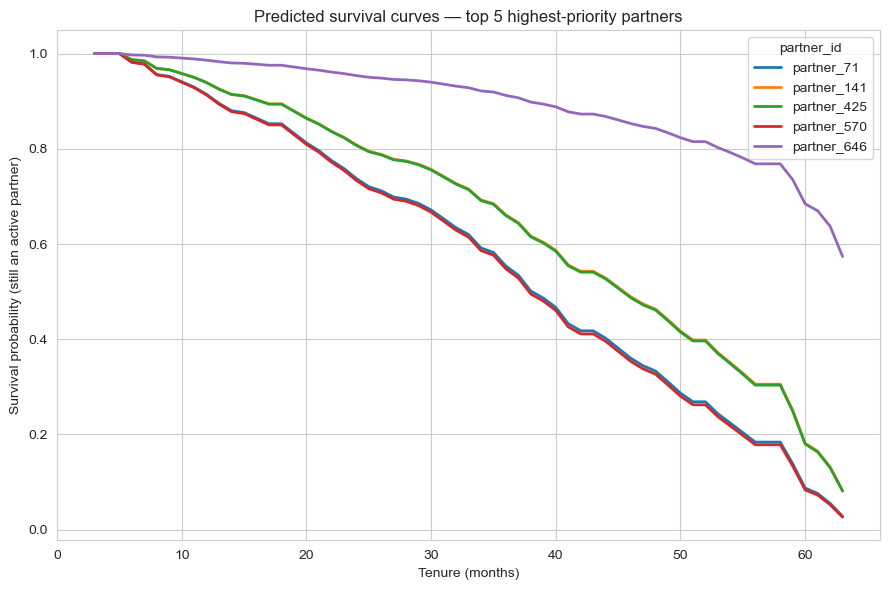

In [38]:
example_ids = risk_df.head(5)["partner_id"].tolist()
survival_df_reset = survival_df.reset_index(drop=True)
cph_input_reset = cph_input.reset_index(drop=True)
example_mask = survival_df_reset["partner_id"].isin(example_ids)

example_rows = cph_input_reset[example_mask.values]
example_labels = survival_df_reset.loc[example_mask, "partner_id"].values

sf = cph.predict_survival_function(example_rows)
sf.columns = example_labels

plt.figure(figsize=(9, 6))
for col in sf.columns:
    plt.plot(sf.index, sf[col], label=col, linewidth=2)
plt.xlabel("Tenure (months)")
plt.ylabel("Survival probability (still an active partner)")
plt.title("Predicted survival curves — top 5 highest-priority partners")
plt.legend(title="partner_id")
plt.tight_layout()
plt.savefig(IMAGES_DIR / "survival_curves_example.png", dpi=150, bbox_inches="tight")
plt.show()

**When this view earns its place over the classifier alone:** imagine two partners both flagged High Risk with nearly identical churn probability. The classifier treats them as equally urgent. Their survival curves might not agree — one could show a steep drop-off in the next month or two, the other a much shallower decline stretched over a year. Same binary flag, very different real urgency. That's the case for pulling this view in specifically when *sequencing* matters: not just "who's at risk" (the classifier's job) but "who do we call first" (this model's job) — most useful when the high-risk list is longer than what capacity allows in a single cycle, exactly the situation Section 5.1 already assumes.

**One natural extension worth naming, deliberately out of scope here:** because this dataset now has three timestamped snapshots per partner (Section 2's temporal structure), it's already shaped for lifelines' `CoxTimeVaryingFitter`, which would let covariates genuinely vary over time instead of being fixed at the current snapshot — a more rigorous survival model than what's built here, and a reasonable next step if this proves useful.

## 10. Conclusion & Business Recommendation

**What this round of changes actually fixed, concretely:**

1. **The seasonality bug was real and now demonstrably fixed.** 23 mature seasonal partners whose old trend reading looked like a ~30% decline were just in their normal season — `gtv_trend_yoy_3m` and `gtv_seasonal_deviation_pct` read them correctly as neutral. Any partner program with seasonal segments (retail-adjacent partners, in particular) was at real risk of flooding outreach lists with false alarms every low season under the old feature.
2. **New partners get a feature set that matches what's actually knowable about them**, rather than an unreliable trend estimate built on a few months of noisy history. `scoring_path` makes that distinction explicit and auditable in the output, rather than silently blending two different kinds of estimate into one number.
3. **The temporal split is a more honest measure of real-world performance.** Metrics moved from LR 0.650/0.650/0.650/0.916 (precision/recall/f1/ROC-AUC, random split) to 0.597/0.562/0.579/0.878 (temporal split) — expected, and a more trustworthy number to plan around than the original evaluation.
4. **The cost-based threshold work surfaced something more useful than a single number**: under realistic cost assumptions, a flat probability cutoff either flags almost nobody or almost everybody. The right output isn't one threshold — it's a capacity-aware ranking by expected cost of inaction, which is what actually ships in Section 8.
5. **SHAP turns "flagged" into "flagged because."** A partner manager can now see the same quantified breakdown for a specific partner that a data scientist would use to sanity-check the model.
6. **Survival analysis adds urgency to risk.** Two partners at the same probability can have very different expected time-to-churn — useful specifically when the high-risk list is longer than the team can act on in one cycle.

**Which model to use:** Logistic Regression remains the best model by recall on both `validation` and `test` in this run, with the added benefit that its coefficients (and now its SHAP values) are directly explainable — useful both for building trust in the system and for coaching partner managers on *why* an account is flagged. This didn't change from before the temporal split, which is itself a useful confirmation: the winner wasn't an artifact of the easier random-split evaluation.

**How I'd operationalize this:**
1. **Retrain on a rolling snapshot window.** Each new quarter, add one snapshot to the historical partner-quarter table and re-run train/validation/test on the three most recent, rather than accumulating an ever-growing single random split.
2. **Score the current book every cycle** using Section 8's approach — refit on every prior labeled snapshot, score the current one — and route partners into capacity-sized tiers, not an arbitrary probability cutoff.
3. **Pair every score with its SHAP explanation and its `scoring_path`**, so outreach is never generic and a partner manager can tell at a glance whether they're looking at a mature trend read or a new-partner cohort benchmark.
4. **Use the survival view to sequence, not just prioritize**, when the high-risk list outgrows capacity in a given cycle.
5. **Feed outcomes back into the model every cycle** — the whole point of a rolling snapshot table is that this gets easier over time, not harder.
6. **Treat this as decision support, not a verdict**, at every step above — the model surfaces where attention is most needed and roughly how urgently; the partner manager's judgment and relationship context still drive the actual conversation.

**The reflection that still matters most, if anything more now than before:** none of the six fixes in this round were about swapping in a fancier algorithm — Logistic Regression won before this round of changes and still wins after it. Every fix was about the *inputs* being wrong or incomplete: a trend feature that misread seasonality, features forced onto partners who didn't have enough history to support them, a validation split that didn't reflect how the model would actually be used, thresholds untethered from real costs. **Data quality, feature correctness, and evaluation methodology matter more for model performance than algorithm choice or hyperparameter tuning** — this round of work is a direct demonstration of that, not just a restated claim. If I were prioritizing where to invest next in a real partner program, it would still be making sure NPS surveys get filled out, engagement events get logged consistently, and contact history is tracked reliably — the same conclusion as before, now with six more concrete examples of what "getting the inputs right" actually looks like in practice.

## 11. Putting this into production

The core operational guidance from before still holds — retrain monthly, monitor for drift, run data quality checks before every scoring cycle — with several updates this round of changes makes necessary:

- **Retraining now means rolling the snapshot window forward**, not just refitting on more of the same static extract: each cycle, generate a new "current" snapshot, demote the current `test` to `validation` and `validation` to `train` (or accumulate a longer historical table and re-slice), and re-run model selection. `src/data_pipeline.py`'s `build_snapshot_dataset` is built for exactly this.
- **New monitoring signals**: the `scoring_path` mix (a sudden shift in what fraction of the book is `new_partner` signals either real onboarding-volume change or a data problem), the STL fallback count from `compute_seasonal_deviation` (should stay near zero given the 27+ month trailing-history floor — a rising count means something upstream shortened available history), the stability of `t*`/the cost curve shape cycle to cycle, and drift in median predicted survival time from the Cox model as an early-warning signal distinct from the classifier's own metrics.
- **Data quality checks now also need to cover**: cohort cell sizes for the new-partner ramp benchmark (a cohort shrinking below the fallback threshold silently degrades that feature), and confirming `mature_mask_values` from the current training fit haven't drifted wildly from the previous cycle's (a big jump usually means the *mature* population's typical GTV trend shifted for a real business reason, worth a manual look before trusting it).

Full detail lives in [`docs/production_considerations.md`](../docs/production_considerations.md), which I'm updating alongside this notebook to reflect all of the above.